# Experiment: MSFT 1-Minute Hybrid iTransformer Forecast (Phase 3 v9.3)

1. Replaces the pure GRU encoder with a hybrid iTransformer + GRU encoder.
2. Preserves the V8.5 walk-forward training and strictly causal rolling backtest pipeline.
3. Adds architecture smoke tests so the hybrid encoder can be validated in-notebook.

Base architecture preserved:
- Probabilistic decoder heads
- Autoregressive recursive generation
- Strict candle validity enforcement
- Strictly causal rolling walk-forward backtest


## Package Installation & Imports

In [1]:
import importlib.util
import subprocess
import sys

required = {
    'alpaca': 'alpaca-py',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'pandas_market_calendars': 'pandas-market-calendars',
}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('All required third-party packages are already installed.')

All required third-party packages are already installed.


In [2]:
from __future__ import annotations
import copy
import gc
import math
import os
import random
import time
from contextlib import nullcontext
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from enum import Enum
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True,max_split_size_mb:128')

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
from alpaca.data.enums import DataFeed
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import Patch, Rectangle
from torch.utils.data import DataLoader, Dataset

print("Imports complete")


Imports complete


## Random Seed & Device Setup

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_TOTAL_MEM_GB = 0.0
if torch.cuda.is_available():
    GPU_TOTAL_MEM_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

LOW_VRAM_MODE = DEVICE.type == 'cuda' and GPU_TOTAL_MEM_GB <= 8.5
PIN_MEMORY = DEVICE.type == 'cuda'
TRAIN_NUM_WORKERS = 0

print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'GPU memory: {GPU_TOTAL_MEM_GB:.2f} GiB')
print(f'Low-VRAM mode: {LOW_VRAM_MODE}')

Using device: cuda
GPU: NVIDIA GeForce RTX 3070
GPU memory: 8.00 GiB
Low-VRAM mode: True


## Configuration

In [4]:
# Data Configuration
SYMBOL = 'MSFT'
LOOKBACK_DAYS = 120
OHLC_COLS = ['Open', 'High', 'Low', 'Close']
RAW_COLS = OHLC_COLS + ['Volume', 'TradeCount', 'VWAP']
BASE_CORE_FEATURES = [
    'rOpen',
    'rHigh',
    'rLow',
    'rClose',
    'logVolChange',
    'logTradeCountChange',
    'vwapDelta',
    'rangeFrac',
    'orderFlowProxy',
    'tickPressure',
]
BASE_FEATURE_COLS = BASE_CORE_FEATURES.copy()
TARGET_COLS = ['rOpen', 'rHigh', 'rLow', 'rClose']
INPUT_EXTRA_COL = 'imputedFracWindow'

HORIZON = 50
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
BASE_LOOKBACK_CANDIDATES = [64, 96, 160, 256]
LOOKBACK_CANDIDATES = [64, 96] if LOW_VRAM_MODE else BASE_LOOKBACK_CANDIDATES.copy()
DEFAULT_LOOKBACK = 96
ENABLE_LOOKBACK_SWEEP = True
SKIP_OPEN_BARS_TARGET = 6


In [5]:
# Model Configuration
HIDDEN_SIZE = 256  # Increased for better generation capacity
NUM_LAYERS = 2
DROPOUT = 0.20     # Slightly higher for stochasticity
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-5
BASE_BATCH_SIZE = 256
BATCH_SIZE = 32 if LOW_VRAM_MODE else BASE_BATCH_SIZE
EVAL_BATCH_SIZE = 32 if LOW_VRAM_MODE else BASE_BATCH_SIZE
ENABLE_AMP = DEVICE.type == 'cuda'


In [6]:
# Phase 3: iTransformer Configuration
D_MODEL = 128
N_HEADS = 8
N_LAYERS = 2


In [7]:
# Training Configuration
SWEEP_MAX_EPOCHS = 15
SWEEP_PATIENCE = 5
FINAL_MAX_EPOCHS = 60  # More epochs for convergence
FINAL_PATIENCE = 12
TF_START = 1.0
TF_END = 0.0
TF_DECAY_RATE = 0.95

In [8]:
# Loss Configuration
RANGE_LOSS_WEIGHT = 0.3
VOLATILITY_WEIGHT = 0.5  # Encourage proper volatility
DIR_PENALTY_WEIGHT = 0.1
STEP_LOSS_POWER = 1.5

In [9]:
# Inference Configuration - v7.5 Ensemble Settings
SAMPLING_TEMPERATURE = 1.5  # >1.0 = more volatile/wild, <1.0 = conservative
BASE_ENSEMBLE_SIZE = 20
ENSEMBLE_SIZE = 8 if LOW_VRAM_MODE else BASE_ENSEMBLE_SIZE
TREND_LOOKBACK_BARS = 20    # Number of bars for historical trend calculation
STRONG_TREND_THRESHOLD = 0.002  # Slope threshold for strong trend rejection
VOLATILITY_SCALING = True   # Match recent realized vol
MIN_PREDICTED_VOL = 0.0001  # Minimum volatility to prevent flat lines

In [10]:
# Data Processing Configuration
STANDARDIZE_TARGETS = False
APPLY_CLIPPING = True
CLIP_QUANTILES = (0.001, 0.999)
DIRECTION_EPS = 0.0001
STD_RATIO_TARGET_MIN = 0.3

In [11]:
# Alpaca API Configuration
ALPACA_FEED = os.getenv('ALPACA_FEED', 'iex').strip().lower()
SESSION_TZ = 'America/New_York'
REQUEST_CHUNK_DAYS = 5
MAX_REQUESTS_PER_MINUTE = 120
MAX_RETRIES = 5
MAX_SESSION_FILL_RATIO = 0.15

In [12]:
# Print Configuration Summary
summary = {
    'version': 'v9.3',
    'phase': 'Phase 3: iTransformer Architecture',
    'symbol': SYMBOL,
    'lookback_days': LOOKBACK_DAYS,
    'horizon': HORIZON,
    'feature_dim': len(BASE_FEATURE_COLS),
    'ensemble_size': ENSEMBLE_SIZE,
    'sampling_temperature': SAMPLING_TEMPERATURE,
    'device': str(DEVICE),
    'gpu_total_mem_gb': round(GPU_TOTAL_MEM_GB, 2),
    'low_vram_mode': LOW_VRAM_MODE,
    'batch_size': BATCH_SIZE,
    'eval_batch_size': EVAL_BATCH_SIZE,
    'amp_enabled': ENABLE_AMP,
    'lookback_candidates': LOOKBACK_CANDIDATES,
}

if 'TECHNICAL_FEATURE_COLS' in globals():
    summary['technical_feature_count'] = len(TECHNICAL_FEATURE_COLS)
if 'REGIME_FEATURE_COLS' in globals():
    summary['regime_feature_count'] = len(REGIME_FEATURE_COLS)
if 'D_MODEL' in globals():
    summary['d_model'] = D_MODEL
if 'N_HEADS' in globals():
    summary['n_heads'] = N_HEADS
if 'N_LAYERS' in globals():
    summary['n_layers'] = N_LAYERS
if 'USE_FREQUENCY' in globals():
    summary['use_frequency'] = USE_FREQUENCY
    summary['multiscale_n_ffts'] = MULTISCALE_N_FFTS
if 'RAG_EMBEDDING_DIM' in globals():
    summary['rag_embedding_dim'] = RAG_EMBEDDING_DIM
    summary['rag_k_retrieve'] = RAG_K_RETRIEVE
    summary['rag_blend_weight'] = RAG_BLEND_WEIGHT
if 'RL_CONFIG' in globals():
    summary['rl_training_steps'] = RL_CONFIG['rl_training_steps']
    summary['run_rl_training'] = RUN_RL_TRAINING

print(summary)


{'version': 'v9.3', 'phase': 'Phase 3: iTransformer Architecture', 'symbol': 'MSFT', 'lookback_days': 120, 'horizon': 50, 'feature_dim': 10, 'ensemble_size': 8, 'sampling_temperature': 1.5, 'device': 'cuda', 'gpu_total_mem_gb': 8.0, 'low_vram_mode': True, 'batch_size': 32, 'eval_batch_size': 32, 'amp_enabled': True, 'lookback_candidates': [64, 96], 'd_model': 128, 'n_heads': 8, 'n_layers': 2}


## Data Fetching Functions

In [13]:
class RequestPacer:
    def __init__(self, max_calls_per_minute: int):
        if max_calls_per_minute <= 0:
            raise ValueError('max_calls_per_minute must be >0')
        self.min_interval = 60.0 / float(max_calls_per_minute)
        self.last_call_ts = 0.0

    def wait(self) -> None:
        now = time.monotonic()
        elapsed = now - self.last_call_ts
        if elapsed < self.min_interval:
            time.sleep(self.min_interval - elapsed)
        self.last_call_ts = time.monotonic()

In [14]:
def _require_alpaca_credentials() -> tuple[str, str]:
    api_key = os.getenv('ALPACA_API_KEY')
    secret_key = os.getenv('ALPACA_SECRET_KEY')
    if not api_key or not secret_key:
        raise RuntimeError('Missing ALPACA_API_KEY / ALPACA_SECRET_KEY.')
    return api_key, secret_key

def _resolve_feed(feed_name: str) -> DataFeed:
    mapping = {'iex': DataFeed.IEX, 'sip': DataFeed.SIP, 'delayed_sip': DataFeed.DELAYED_SIP}
    k = feed_name.strip().lower()
    if k not in mapping:
        raise ValueError(f'Unsupported ALPACA_FEED={feed_name!r}. Use one of: {list(mapping)}')
    return mapping[k]

In [15]:
def fetch_bars_alpaca(symbol: str, lookback_days: int) -> tuple[pd.DataFrame, int]:
    api_key, secret_key = _require_alpaca_credentials()
    client = StockHistoricalDataClient(api_key=api_key, secret_key=secret_key)
    feed = _resolve_feed(ALPACA_FEED)
    pacer = RequestPacer(MAX_REQUESTS_PER_MINUTE)

    end_ts = datetime.now(timezone.utc).replace(second=0, microsecond=0)
    if ALPACA_FEED in {'sip', 'delayed_sip'}:
        end_ts = end_ts - timedelta(minutes=20)
    start_ts = end_ts - timedelta(days=lookback_days)

    parts = []
    cursor = start_ts
    calls = 0

    while cursor < end_ts:
        chunk_end = min(cursor + timedelta(days=REQUEST_CHUNK_DAYS), end_ts)
        chunk = None
        for attempt in range(1, MAX_RETRIES + 1):
            pacer.wait()
            calls += 1
            try:
                req = StockBarsRequest(
                    symbol_or_symbols=[symbol],
                    timeframe=TimeFrame.Minute,
                    start=cursor,
                    end=chunk_end,
                    feed=feed,
                    limit=10000,
                )
                chunk = client.get_stock_bars(req).df
                break
            except Exception as exc:
                msg = str(exc).lower()
                if ('429' in msg or 'rate limit' in msg) and attempt < MAX_RETRIES:
                    backoff = min(2 ** attempt, 30)
                    print(f'Rate-limited; sleeping {backoff}s (attempt {attempt}/{MAX_RETRIES}).')
                    time.sleep(backoff)
                    continue
                if ('subscription' in msg or 'forbidden' in msg) and ALPACA_FEED != 'iex':
                    raise RuntimeError('Feed unavailable for account. Use ALPACA_FEED=iex or upgrade subscription.') from exc
                raise
        if chunk is not None and not chunk.empty:
            d = chunk.reset_index().rename(columns={
                'timestamp': 'Datetime', 'open': 'Open', 'high': 'High',
                'low': 'Low', 'close': 'Close', 'volume': 'Volume',
                'trade_count': 'TradeCount', 'vwap': 'VWAP',
            })
            if 'Volume' not in d.columns:
                d['Volume'] = 0.0
            if 'TradeCount' not in d.columns:
                d['TradeCount'] = 0.0
            if 'VWAP' not in d.columns:
                d['VWAP'] = d['Close']

            need = ['Datetime'] + RAW_COLS
            d['Datetime'] = pd.to_datetime(d['Datetime'], utc=True)
            d = d[need].dropna(subset=OHLC_COLS).set_index('Datetime').sort_index()
            parts.append(d)
        cursor = chunk_end

    if not parts:
        raise RuntimeError('No bars returned from Alpaca.')
    out = pd.concat(parts, axis=0).sort_index()
    out = out[~out.index.duplicated(keep='last')]
    return out.astype(np.float32), calls

In [16]:
def sessionize_with_calendar(df_utc: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    if df_utc.empty:
        raise RuntimeError('Input bars are empty.')

    idx = pd.DatetimeIndex(df_utc.index)
    if idx.tz is None:
        idx = idx.tz_localize('UTC')
    else:
        idx = idx.tz_convert('UTC')

    df_utc = df_utc.copy()
    df_utc.index = idx

    cal = mcal.get_calendar('XNYS')
    sched = cal.schedule(
        start_date=(idx.min() - pd.Timedelta(days=2)).date(),
        end_date=(idx.max() + pd.Timedelta(days=2)).date(),
    )

    pieces = []
    fill_ratios = []

    for sid, (_, row) in enumerate(sched.iterrows()):
        open_ts = pd.Timestamp(row['market_open'])
        close_ts = pd.Timestamp(row['market_close'])

        if open_ts.tzinfo is None:
            open_ts = open_ts.tz_localize('UTC')
        else:
            open_ts = open_ts.tz_convert('UTC')
        if close_ts.tzinfo is None:
            close_ts = close_ts.tz_localize('UTC')
        else:
            close_ts = close_ts.tz_convert('UTC')

        exp_idx = pd.date_range(open_ts, close_ts, freq='1min', inclusive='left')
        if len(exp_idx) == 0:
            continue

        day = df_utc[(df_utc.index >= open_ts) & (df_utc.index < close_ts)]
        day = day.reindex(exp_idx)
        imputed = day[OHLC_COLS].isna().any(axis=1).to_numpy()
        fill_ratio = float(imputed.mean())

        if fill_ratio >= 1.0 or fill_ratio > MAX_SESSION_FILL_RATIO:
            continue

        day[OHLC_COLS + ['VWAP']] = day[OHLC_COLS + ['VWAP']].ffill().bfill()
        if day['VWAP'].isna().all():
            day['VWAP'] = day['Close']
        else:
            day['VWAP'] = day['VWAP'].fillna(day['Close'])

        day['Volume'] = day['Volume'].fillna(0.0)
        day['TradeCount'] = day['TradeCount'].fillna(0.0)
        day['is_imputed'] = imputed.astype(np.int8)
        day['session_id'] = int(sid)
        day['bar_in_session'] = np.arange(len(day), dtype=np.int32)
        day['session_len'] = int(len(day))

        if day[RAW_COLS].isna().any().any():
            raise RuntimeError('NaNs remain after per-session fill.')
        pieces.append(day)
        fill_ratios.append(fill_ratio)

    if not pieces:
        raise RuntimeError('No sessions kept after calendar filtering.')

    out = pd.concat(pieces, axis=0).sort_index()
    out.index = out.index.tz_convert(SESSION_TZ).tz_localize(None)
    out = out.copy()

    for c in RAW_COLS:
        out[c] = out[c].astype(np.float32)
    out['is_imputed'] = out['is_imputed'].astype(np.int8)
    out['session_id'] = out['session_id'].astype(np.int32)
    out['bar_in_session'] = out['bar_in_session'].astype(np.int32)
    out['session_len'] = out['session_len'].astype(np.int32)

    meta = {
        'calendar_sessions_total': int(len(sched)),
        'kept_sessions': int(len(pieces)),
        'avg_fill_ratio_kept': float(np.mean(fill_ratios)) if fill_ratios else float('nan'),
    }
    return out, meta

## Fetch Data from Alpaca

In [17]:
raw_df_utc, api_calls = fetch_bars_alpaca(SYMBOL, LOOKBACK_DAYS)
price_df, session_meta = sessionize_with_calendar(raw_df_utc)
print(f'Raw rows from Alpaca: {len(raw_df_utc):,}')
print(f'Sessionized rows kept: {len(price_df):,}')
print('Session meta:', session_meta)

min_needed = max(LOOKBACK_CANDIDATES) + HORIZON + 1000
if len(price_df) < min_needed:
    raise RuntimeError(f'Not enough rows after session filtering ({len(price_df)}). Need at least {min_needed}.')

Raw rows from Alpaca: 31,653
Sessionized rows kept: 31,020
Session meta: {'calendar_sessions_total': 83, 'kept_sessions': 80, 'avg_fill_ratio_kept': 0.0043177655677655675}


## Feature Engineering Functions

In [18]:
def enforce_candle_validity(ohlc: np.ndarray) -> np.ndarray:
    out = np.asarray(ohlc, dtype=np.float32)
    o, h, l, c = out[:, 0], out[:, 1], out[:, 2], out[:, 3]
    out[:, 1] = np.maximum.reduce([h, o, c])
    out[:, 2] = np.minimum.reduce([l, o, c])
    return out

def returns_to_prices_seq(return_ohlc: np.ndarray, last_close: float) -> np.ndarray:
    seq = []
    prev_close = float(last_close)
    for rO, rH, rL, rC in np.asarray(return_ohlc, dtype=np.float32):
        o = prev_close * np.exp(float(rO))
        h = prev_close * np.exp(float(rH))
        l = prev_close * np.exp(float(rL))
        c = prev_close * np.exp(float(rC))
        cand = enforce_candle_validity(np.array([[o, h, l, c]], dtype=np.float32))[0]
        seq.append(cand)
        prev_close = float(cand[3])
    return np.asarray(seq, dtype=np.float32)

In [19]:
def build_feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    eps = 1e-9
    g = df.groupby('session_id', sort=False)
    prev_close = g['Close'].shift(1)
    prev_close = prev_close.fillna(df['Open'])
    prev_vol = g['Volume'].shift(1).fillna(df['Volume'])
    prev_tc = g['TradeCount'].shift(1).fillna(df['TradeCount'])
    prev_imp = g['is_imputed'].shift(1).fillna(0).astype(bool)

    row_imputed = (df['is_imputed'].astype(bool) | prev_imp)
    row_open_skip = (df['bar_in_session'].astype(int) < SKIP_OPEN_BARS_TARGET)

    out = pd.DataFrame(index=df.index, dtype=np.float32)
    out['rOpen'] = np.log(df['Open'] / (prev_close + eps))
    out['rHigh'] = np.log(df['High'] / (prev_close + eps))
    out['rLow'] = np.log(df['Low'] / (prev_close + eps))
    out['rClose'] = np.log(df['Close'] / (prev_close + eps))
    out['logVolChange'] = np.log((df['Volume'] + 1.0) / (prev_vol + 1.0))
    out['logTradeCountChange'] = np.log((df['TradeCount'] + 1.0) / (prev_tc + 1.0))
    out['vwapDelta'] = np.log((df['VWAP'] + eps) / (df['Close'] + eps))
    out['rangeFrac'] = np.maximum(out['rHigh'] - out['rLow'], 0) / (np.abs(out['rClose']) + eps)

    signed_body = (df['Close'] - df['Open']) / ((df['High'] - df['Low']) + eps)
    out['orderFlowProxy'] = signed_body * np.log1p(df['Volume'])
    out['tickPressure'] = np.sign(df['Close'] - df['Open']) * np.log1p(df['TradeCount'])

    out['row_imputed'] = row_imputed.astype(np.int8).to_numpy()
    out['row_open_skip'] = row_open_skip.astype(np.int8).to_numpy()
    out['prev_close'] = prev_close.astype(np.float32).to_numpy()
    return out.astype(np.float32)

def build_target_frame(feat_df: pd.DataFrame) -> pd.DataFrame:
    return feat_df[TARGET_COLS].copy().astype(np.float32)

In [20]:
feat_df = build_feature_frame(price_df)
target_df = build_target_frame(feat_df)

missing_feature_cols = [col for col in BASE_FEATURE_COLS if col not in feat_df.columns]
if missing_feature_cols:
    raise RuntimeError(f'Missing engineered features: {missing_feature_cols}')

print('Feature rows:', len(feat_df))
print('Feature dimension:', len(BASE_FEATURE_COLS))
print('Target columns:', list(target_df.columns))
print('Feature preview:', BASE_FEATURE_COLS[:5], '...', BASE_FEATURE_COLS[-5:])


Feature rows: 31020
Feature dimension: 10
Target columns: ['rOpen', 'rHigh', 'rLow', 'rClose']
Feature preview: ['rOpen', 'rHigh', 'rLow', 'rClose', 'logVolChange'] ... ['logTradeCountChange', 'vwapDelta', 'rangeFrac', 'orderFlowProxy', 'tickPressure']


## Windowing & Dataset Functions

In [21]:
def split_points(n_rows: int) -> tuple[int, int]:
    tr = int(n_rows * TRAIN_RATIO)
    va = int(n_rows * (TRAIN_RATIO + VAL_RATIO))
    return tr, va

def build_walkforward_slices(price_df_full: pd.DataFrame) -> list[tuple[str, int, int]]:
    n = len(price_df_full)
    span = int(round(n * 0.85))
    shift = max(1, n - span)
    cands = [('slice_1', 0, min(span, n)), ('slice_2', shift, min(shift + span, n))]
    out = []
    seen = set()
    for name, a, b in cands:
        key = (a, b)
        if key in seen or b - a < max(LOOKBACK_CANDIDATES) + HORIZON + 1400:
            continue
        out.append((name, a, b))
        seen.add(key)
    return out if out else [('full', 0, n)]

In [22]:
def make_multistep_windows(input_scaled, target_scaled, target_raw, row_imputed, row_open_skip, 
                           starts_prev_close, window, horizon):
    X, y_s, y_r, starts, prev_close = [], [], [], [], []
    dropped_target_imputed, dropped_target_open_skip = 0, 0
    n = len(input_scaled)

    for i in range(window, n - horizon + 1):
        if row_imputed[i:i+horizon].any():
            dropped_target_imputed += 1
            continue
        if row_open_skip[i:i+horizon].any():
            dropped_target_open_skip += 1
            continue

        xb = input_scaled[i-window:i]
        imp_frac = float(row_imputed[i-window:i].mean())
        imp_col = np.full((window, 1), imp_frac, dtype=np.float32)
        xb_aug = np.concatenate([xb, imp_col], axis=1)

        X.append(xb_aug)
        y_s.append(target_scaled[i:i+horizon])
        y_r.append(target_raw[i:i+horizon])
        starts.append(i)
        prev_close.append(starts_prev_close[i])

    return (np.asarray(X, dtype=np.float32), np.asarray(y_s, dtype=np.float32),
            np.asarray(y_r, dtype=np.float32), np.asarray(starts, dtype=np.int64),
            np.asarray(prev_close, dtype=np.float32), dropped_target_imputed, dropped_target_open_skip)

In [23]:
class MultiStepDataset(Dataset):
    def __init__(self, X, y_s, y_r):
        self.X = torch.from_numpy(X).float()
        self.y_s = torch.from_numpy(y_s).float()
        self.y_r = torch.from_numpy(y_r).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y_s[idx], self.y_r[idx]

In [24]:
slices = build_walkforward_slices(price_df)
print('Walk-forward slices:', slices)

Walk-forward slices: [('slice_1', 0, 26367), ('slice_2', 4653, 31020)]


## Phase 3: Hybrid iTransformer Model

In [25]:
class SinusoidalPositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for time dimension."""
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * 
                           -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term) if d_model % 2 == 0 else torch.cos(position * div_term[:-1])
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class iTransformerEncoderLayer(nn.Module):
    """
    iTransformer Encoder Layer with variable attention (across features, NOT time).
    Key innovation: [batch, time, features] -> [batch, features, time, d_model]
    """
    def __init__(self, d_model: int, n_heads: int, dim_feedforward: int = 512, 
                 dropout: float = 0.1, activation: str = 'gelu'):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True
        )
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = F.gelu if activation == 'gelu' else F.relu

    def forward(self, src: torch.Tensor, src_mask: Optional[torch.Tensor] = None,
                src_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Args: src: [batch, num_features, time, d_model] - Inverted format!
        Returns: out: [batch, num_features, time, d_model]
        """
        b, n_var, t, d = src.shape
        src_reshaped = src.permute(0, 2, 1, 3).reshape(b * t, n_var, d)
        src2 = self.norm1(src_reshaped)
        attn_out, _ = self.self_attn(src2, src2, src2, 
                                      attn_mask=src_mask,
                                      key_padding_mask=src_key_padding_mask,
                                      need_weights=False)
        src_reshaped = src_reshaped + self.dropout1(attn_out)
        src = src_reshaped.reshape(b, t, n_var, d).permute(0, 2, 1, 3)
        src2 = self.norm2(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src2))))
        src = src + self.dropout2(src2)
        return src


class iTransformerEncoder(nn.Module):
    """
    iTransformer Encoder with input projection, positional encoding,
    stack of iTransformerEncoderLayer, and global average pooling.
    """
    def __init__(self, input_size: int, d_model: int = 128, n_heads: int = 8, 
                 n_layers: int = 2, dim_feedforward: int = 512, dropout: float = 0.1,
                 max_len: int = 5000):
        super().__init__()
        self.d_model = d_model
        self.input_size = input_size
        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoder = SinusoidalPositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            iTransformerEncoderLayer(d_model, n_heads, dim_feedforward, dropout)
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        """
        Args: src: [batch, time, input_size]
        Returns: out: [batch, input_size * d_model]
        """
        batch_size, time_len, n_features = src.shape
        src = src.transpose(1, 2).unsqueeze(-1)  # [batch, n_features, time, 1]
        src = self.input_projection(src)  # [batch, n_features, time, d_model]
        src = src.reshape(batch_size * n_features, time_len, self.d_model)
        src = self.pos_encoder(src)
        src = src.reshape(batch_size, n_features, time_len, self.d_model)
        for layer in self.layers:
            src = layer(src)
        src = src.mean(dim=2)  # [batch, n_features, d_model]
        src = src.reshape(batch_size, -1)  # [batch, n_features * d_model]
        return src


class HybridEncoder(nn.Module):
    """Hybrid Encoder combining iTransformer + GRU."""
    def __init__(self, input_size: int, d_model: int = 128, n_heads: int = 8, 
                 n_layers: int = 2, hidden_size: int = 256, num_gru_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()
        self.input_size = input_size
        self.d_model = d_model
        self.hidden_size = hidden_size
        self.itransformer = iTransformerEncoder(
            input_size=input_size, d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, dropout=dropout
        )
        self.gru = nn.GRU(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_gru_layers, batch_first=True,
            dropout=dropout if num_gru_layers > 1 else 0.0
        )
        fusion_input_size = input_size * d_model + hidden_size
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_size, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
        )
        self.output_norm = nn.LayerNorm(hidden_size)

    def forward(self, src: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args: src: [batch, time, input_size]
        Returns: fused: [batch, hidden_size], gru_out: [batch, time, hidden_size]
        """
        itrans_out = self.itransformer(src)
        gru_out, gru_hidden = self.gru(src)
        gru_last = gru_hidden[-1]
        combined = torch.cat([itrans_out, gru_last], dim=-1)
        fused = self.fusion(combined)
        fused = self.output_norm(fused)
        return fused, gru_out


print('✓ Phase 3: iTransformer architecture components defined')
print(f'  - d_model: {D_MODEL}')
print(f'  - n_heads: {N_HEADS}')
print(f'  - n_layers: {N_LAYERS}')
print(f'  - hidden_size: {HIDDEN_SIZE}')

class Seq2SeqAttnGRU(nn.Module):
    """
    Seq2Seq with Hybrid Encoder (iTransformer + GRU) and GRU Decoder.
    Replaces Seq2SeqAttnGRU encoder with HybridEncoder.
    """
    def __init__(self, input_size, output_size, d_model=D_MODEL, n_heads=N_HEADS,
                 n_layers=N_LAYERS, hidden_size=HIDDEN_SIZE, num_gru_layers=None,
                 dropout=DROPOUT, horizon=HORIZON, num_layers=None):
        super().__init__()
        if num_gru_layers is None:
            num_gru_layers = NUM_LAYERS if num_layers is None else num_layers
        elif num_layers is not None and num_layers != num_gru_layers:
            raise ValueError('Use only one of num_gru_layers or the legacy num_layers alias.')
        self.horizon = horizon
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.d_model = d_model
        self.encoder = HybridEncoder(
            input_size=input_size, d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, hidden_size=hidden_size,
            num_gru_layers=num_gru_layers, dropout=dropout
        )
        self.decoder_cell = nn.GRUCell(output_size + hidden_size, hidden_size)
        self.attn_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.mu_head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, output_size),
        )
        self.log_sigma_head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size // 2),
            nn.GELU(),
            nn.Linear(hidden_size // 2, output_size),
        )
        nn.init.xavier_uniform_(self.mu_head[-1].weight, gain=0.1)
        nn.init.zeros_(self.mu_head[-1].bias)
        nn.init.zeros_(self.log_sigma_head[-1].weight)
        nn.init.zeros_(self.log_sigma_head[-1].bias)

    def _attend(self, h_dec, enc_out):
        query = self.attn_proj(h_dec).unsqueeze(2)
        scores = torch.bmm(enc_out, query).squeeze(2)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), enc_out).squeeze(1)
        return context

    def forward(self, x, y_teacher=None, teacher_forcing_ratio=0.0, return_sigma=False):
        h_dec, enc_out = self.encoder(x)
        dec_input = x[:, -1, :self.output_size]
        mu_seq, sigma_seq = [], []
        for t in range(self.horizon):
            context = self._attend(h_dec, enc_out)
            cell_input = torch.cat([dec_input, context], dim=1)
            h_dec = self.decoder_cell(cell_input, h_dec)
            out_features = torch.cat([h_dec, context], dim=1)
            mu = self.mu_head(out_features)
            log_sigma = self.log_sigma_head(out_features)
            mu_seq.append(mu.unsqueeze(1))
            sigma_seq.append(log_sigma.unsqueeze(1))
            if y_teacher is not None and teacher_forcing_ratio > 0.0:
                if teacher_forcing_ratio >= 1.0 or torch.rand(1).item() < teacher_forcing_ratio:
                    dec_input = y_teacher[:, t, :]
                else:
                    noise = torch.randn_like(mu) * torch.exp(log_sigma).detach()
                    dec_input = mu + noise
            else:
                dec_input = mu
        mu_out = torch.cat(mu_seq, dim=1)
        sigma_out = torch.cat(sigma_seq, dim=1)
        if return_sigma:
            return mu_out, sigma_out
        return mu_out

    def generate_realistic(self, x, temperature=1.0, historical_vol=None, manual_seed=None):
        self.eval()
        with torch.no_grad():
            if manual_seed is not None:
                torch.manual_seed(manual_seed)
            h_dec, enc_out = self.encoder(x)
            dec_input = x[:, -1, :self.output_size]
            generated = []
            for t in range(self.horizon):
                context = self._attend(h_dec, enc_out)
                cell_input = torch.cat([dec_input, context], dim=1)
                h_dec = self.decoder_cell(cell_input, h_dec)
                out_features = torch.cat([h_dec, context], dim=1)
                mu = self.mu_head(out_features)
                log_sigma = self.log_sigma_head(out_features)
                sigma = torch.exp(log_sigma) * temperature
                if historical_vol is not None and t < 5:
                    sigma = torch.ones_like(sigma) * historical_vol
                sigma = torch.maximum(sigma, torch.full_like(sigma, MIN_PREDICTED_VOL))
                noise = torch.randn_like(mu) * sigma
                sample = mu + noise
                generated.append(sample.unsqueeze(1))
                dec_input = sample
            return torch.cat(generated, dim=1)


print('✓ Seq2SeqAttnGRU model defined with iTransformer encoder')

✓ Phase 3: iTransformer architecture components defined
  - d_model: 128
  - n_heads: 8
  - n_layers: 2
  - hidden_size: 256
✓ Seq2SeqAttnGRU model defined with iTransformer encoder


### Phase 3 Validation

In [26]:
print('=' * 60)
print('TEST CELL: iTransformer Architecture Validation')
print('=' * 60)

test_batch_size = 4
test_seq_len = 60
test_input_size = 11
test_output_size = 4
test_horizon = 50

test_model = Seq2SeqAttnGRU(
    input_size=test_input_size, output_size=test_output_size,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
    hidden_size=HIDDEN_SIZE, num_gru_layers=NUM_LAYERS,
    dropout=DROPOUT, horizon=test_horizon,
).to(DEVICE)

test_input = torch.randn(test_batch_size, test_seq_len, test_input_size).to(DEVICE)
test_target = torch.randn(test_batch_size, test_horizon, test_output_size).to(DEVICE)

print('\n1. Forward Pass Test:')
mu_out = test_model(test_input)
assert mu_out.shape == (test_batch_size, test_horizon, test_output_size)
print(f'   ✓ Mu output shape: {mu_out.shape}')

mu_out, sigma_out = test_model(test_input, return_sigma=True)
assert sigma_out.shape == (test_batch_size, test_horizon, test_output_size)
print(f'   ✓ Sigma output shape: {sigma_out.shape}')

print('\n2. generate_realistic() Test:')
gen_out = test_model.generate_realistic(test_input, temperature=1.0)
assert gen_out.shape == (test_batch_size, test_horizon, test_output_size)
print(f'   ✓ Generated output shape: {gen_out.shape}')

gen_out1 = test_model.generate_realistic(test_input, temperature=1.0, manual_seed=42)
gen_out2 = test_model.generate_realistic(test_input, temperature=1.0, manual_seed=42)
assert torch.allclose(gen_out1, gen_out2)
print(f'   ✓ Manual seed reproducibility: OK')

print('\n3. Gradient Flow Test:')
test_model.train()
mu_out, sigma_out = test_model(test_input, y_teacher=test_target, teacher_forcing_ratio=0.5, return_sigma=True)
loss = F.mse_loss(mu_out, test_target) + torch.exp(sigma_out).mean()
loss.backward()

has_grads = [name for name, param in test_model.named_parameters() if param.grad is not None]
print(f'   ✓ Parameters with gradients: {len(has_grads)}')
itransformer_grads = [n for n in has_grads if 'itransformer' in n]
print(f'   ✓ iTransformer parameters with gradients: {len(itransformer_grads)}')

print('\n4. Architecture Component Test:')
test_layer = iTransformerEncoderLayer(d_model=D_MODEL, n_heads=N_HEADS).to(DEVICE)
test_layer_input = torch.randn(test_batch_size, test_input_size, test_seq_len, D_MODEL).to(DEVICE)
test_layer_output = test_layer(test_layer_input)
assert test_layer_output.shape == test_layer_input.shape
print(f'   ✓ iTransformerEncoderLayer output shape: {test_layer_output.shape}')

test_enc = iTransformerEncoder(input_size=test_input_size, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS).to(DEVICE)
test_enc_input = torch.randn(test_batch_size, test_seq_len, test_input_size).to(DEVICE)
test_enc_output = test_enc(test_enc_input)
expected_enc_out = test_input_size * D_MODEL
assert test_enc_output.shape == (test_batch_size, expected_enc_out)
print(f'   ✓ iTransformerEncoder output shape: {test_enc_output.shape}')

test_hybrid = HybridEncoder(
    input_size=test_input_size, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS, hidden_size=HIDDEN_SIZE, num_gru_layers=NUM_LAYERS
).to(DEVICE)
test_hybrid_fused, test_hybrid_gru = test_hybrid(test_enc_input)
assert test_hybrid_fused.shape == (test_batch_size, HIDDEN_SIZE)
assert test_hybrid_gru.shape == (test_batch_size, test_seq_len, HIDDEN_SIZE)
print(f'   ✓ HybridEncoder fused output shape: {test_hybrid_fused.shape}')
print(f'   ✓ HybridEncoder GRU output shape: {test_hybrid_gru.shape}')

print('\n5. Parameter Count:')
total_params = sum(p.numel() for p in test_model.parameters())
print(f'   Total parameters: {total_params:,}')
itrans_params = sum(p.numel() for p in test_model.encoder.itransformer.parameters())
gru_enc_params = sum(p.numel() for p in test_model.encoder.gru.parameters())
print(f'   iTransformer encoder: {itrans_params:,}')
print(f'   GRU encoder: {gru_enc_params:,}')

print('\n' + '=' * 60)
print('ALL TESTS PASSED ✓')
print('=' * 60)

TEST CELL: iTransformer Architecture Validation


D:\Miniconda\envs\msft-gru\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(



1. Forward Pass Test:
   ✓ Mu output shape: torch.Size([4, 50, 4])
   ✓ Sigma output shape: torch.Size([4, 50, 4])

2. generate_realistic() Test:
   ✓ Generated output shape: torch.Size([4, 50, 4])
   ✓ Manual seed reproducibility: OK

3. Gradient Flow Test:
   ✓ Parameters with gradients: 53
   ✓ iTransformer parameters with gradients: 26

4. Architecture Component Test:
   ✓ iTransformerEncoderLayer output shape: torch.Size([4, 11, 60, 128])
   ✓ iTransformerEncoder output shape: torch.Size([4, 1408])
   ✓ HybridEncoder fused output shape: torch.Size([4, 256])
   ✓ HybridEncoder GRU output shape: torch.Size([4, 60, 256])

5. Parameter Count:
   Total parameters: 2,644,360
   iTransformer encoder: 396,800
   GRU encoder: 601,344

ALL TESTS PASSED ✓


## Trend Injection Functions (v7.5)

In [27]:
def calculate_trend_slope(prices: np.ndarray) -> float:
    """
    Calculate linear trend slope from price series.
    Returns slope in log-return space per step.
    """
    prices = np.asarray(prices, dtype=np.float32)
    if len(prices) < 2:
        return 0.0

    # Use log prices for trend calculation
    log_prices = np.log(prices)
    x = np.arange(len(log_prices), dtype=np.float32)

    # Simple linear regression: slope = covariance(x, y) / variance(x)
    x_mean = np.mean(x)
    y_mean = np.mean(log_prices)

    numerator = np.sum((x - x_mean) * (log_prices - y_mean))
    denominator = np.sum((x - x_mean) ** 2)

    if denominator < 1e-10:
        return 0.0

    return float(numerator / denominator)


def calculate_path_trend(return_ohlc: np.ndarray) -> float:
    """
    Calculate trend slope from predicted OHLC returns.
    Uses Close prices for trend calculation.
    """
    # Convert returns to close prices (relative to starting point)
    close_returns = return_ohlc[:, 3]  # rClose column
    close_prices = np.exp(np.cumsum(close_returns))
    return calculate_trend_slope(close_prices)


def select_best_path_by_trend(
    all_paths: list[np.ndarray], 
    historical_slope: float,
    strong_trend_threshold: float = 0.002
) -> tuple[int, np.ndarray, dict]:
    """
    Select the path whose trend slope is closest to historical trend.

    Args:
        all_paths: List of generated paths, each [horizon, 4]
        historical_slope: Historical trend slope from input context
        strong_trend_threshold: Threshold for considering trend 'strong'

    Returns:
        best_idx: Index of selected path
        best_path: The selected path
        info: Dict with selection details for visualization
    """
    path_slopes = []
    path_directions = []

    for path in all_paths:
        slope = calculate_path_trend(path)
        path_slopes.append(slope)
        path_directions.append(np.sign(slope))

    path_slopes = np.array(path_slopes)
    path_directions = np.array(path_directions)

    # Check if historical trend is strong
    historical_direction = np.sign(historical_slope)
    is_strong_trend = abs(historical_slope) > strong_trend_threshold

    # Filter paths if strong trend
    if is_strong_trend:
        # Reject paths that go opposite direction
        valid_mask = path_directions == historical_direction
        if not valid_mask.any():
            # If all paths rejected, fall back to all paths
            valid_mask = np.ones(len(all_paths), dtype=bool)
    else:
        valid_mask = np.ones(len(all_paths), dtype=bool)

    # Calculate distance to historical slope for valid paths
    slope_distances = np.abs(path_slopes - historical_slope)
    slope_distances[~valid_mask] = np.inf  # Exclude invalid paths

    # Select path with minimum distance
    best_idx = int(np.argmin(slope_distances))
    best_path = all_paths[best_idx]

    # Build info dict for visualization
    info = {
        'historical_slope': historical_slope,
        'historical_direction': historical_direction,
        'is_strong_trend': is_strong_trend,
        'strong_threshold': strong_trend_threshold,
        'path_slopes': path_slopes.tolist(),
        'path_directions': path_directions.tolist(),
        'valid_mask': valid_mask.tolist(),
        'selected_idx': best_idx,
        'selected_slope': path_slopes[best_idx],
        'rejected_count': int((~valid_mask).sum()),
        'slope_distances': slope_distances[valid_mask].tolist() if valid_mask.any() else [],
    }

    return best_idx, best_path, info


def generate_ensemble_with_trend_selection(
    model, 
    X: np.ndarray,
    context_prices: np.ndarray,
    temperature: float = 1.0,
    ensemble_size: int = 20,
    trend_lookback: int = 20
) -> tuple[np.ndarray, dict]:
    """
    Generate ensemble of paths and select best matching historical trend.

    Args:
        model: Trained Seq2SeqAttnGRU model
        X: Input features [1, window, features]
        context_prices: Historical price context for volatility and trend calc
        temperature: Sampling temperature
        ensemble_size: Number of paths to generate
        trend_lookback: Number of bars to use for trend calculation

    Returns:
        best_path: Selected path [horizon, 4]
        ensemble_info: Dict with all paths and selection info
    """
    model.eval()

    with torch.no_grad():
        X_tensor = torch.from_numpy(X).float().to(DEVICE)

        # Calculate historical volatility from context
        log_returns = np.log(context_prices[1:] / context_prices[:-1])
        historical_vol = float(np.std(log_returns)) if len(log_returns) > 1 else 0.001

        # Calculate historical trend from last N bars of context
        trend_context = context_prices[-trend_lookback:]
        historical_slope = calculate_trend_slope(trend_context)

        print(f"Historical realized vol: {historical_vol:.6f}, Temperature: {temperature}")
        print(f"Historical trend slope (last {trend_lookback} bars): {historical_slope:.6f}")

        # Generate ensemble of paths with different seeds
        all_paths = []
        for i in range(ensemble_size):
            # Use different seed for each path
            seed = SEED + i * 1000
            generated = model.generate_realistic(
                X_tensor, 
                temperature=temperature, 
                historical_vol=historical_vol,
                manual_seed=seed
            )
            all_paths.append(generated.detach().cpu().numpy()[0])  # [horizon, 4]

        # Select best path by trend matching
        best_idx, best_path, selection_info = select_best_path_by_trend(
            all_paths, 
            historical_slope,
            STRONG_TREND_THRESHOLD
        )

        print(f"Generated {ensemble_size} paths, selected path {best_idx}")
        print(f"  Selected path slope: {selection_info['selected_slope']:.6f}")
        print(f"  Strong trend: {selection_info['is_strong_trend']}, Rejected: {selection_info['rejected_count']}")

        # Build ensemble info for visualization
        ensemble_info = {
            'all_paths': all_paths,
            'best_idx': best_idx,
            'best_path': best_path,
            'selection_info': selection_info,
            'historical_vol': historical_vol,
            'temperature': temperature,
        }

        return best_path, ensemble_info

## Loss Functions

In [28]:
def nll_loss(mu, log_sigma, target):
    """Negative log-likelihood for Gaussian"""
    sigma = torch.exp(log_sigma)
    nll = 0.5 * ((target - mu) / sigma) ** 2 + log_sigma + 0.5 * np.log(2 * np.pi)
    return nll.mean()

def candle_range_loss(mu, target):
    pred_range = mu[:, :, 1] - mu[:, :, 2]  # High - Low
    actual_range = target[:, :, 1] - target[:, :, 2]
    return ((pred_range - actual_range) ** 2).mean()

def volatility_match_loss(log_sigma, target):
    """Encourage predicted uncertainty to match actual error magnitude"""
    pred_vol = torch.exp(log_sigma).mean()
    actual_vol = target.std()
    return (pred_vol - actual_vol) ** 2

def directional_penalty(mu, target):
    pred_close = mu[:, :, 3]
    actual_close = target[:, :, 3]
    sign_match = torch.sign(pred_close) * torch.sign(actual_close)
    penalty = torch.clamp(-sign_match, min=0.0)
    return penalty.mean()

## Training Functions

In [29]:
def tf_ratio_for_epoch(epoch):
    ratio = TF_START * (TF_DECAY_RATE ** (epoch - 1))
    return max(float(TF_END), float(ratio))

def amp_autocast():
    if ENABLE_AMP and DEVICE.type == 'cuda':
        return torch.cuda.amp.autocast(dtype=torch.float16)
    return nullcontext()

def clear_torch_memory():
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass

def state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

@torch.no_grad()
def predict_mean_in_batches(model: nn.Module, X: np.ndarray, batch_size: int = EVAL_BATCH_SIZE) -> np.ndarray:
    if len(X) == 0:
        return np.empty((0, HORIZON, len(TARGET_COLS)), dtype=np.float32)

    model.eval()
    outs = []
    for start in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[start:start + batch_size]).float().to(DEVICE, non_blocking=PIN_MEMORY)
        with amp_autocast():
            mu = model(xb)
        outs.append(mu.float().cpu().numpy())
        del xb, mu

    clear_torch_memory()
    return np.concatenate(outs, axis=0)

def run_epoch(model, loader, step_weights_t, optimizer=None, tf_ratio=0.0, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, nll_total, range_total, vol_total, dir_total = 0.0, 0.0, 0.0, 0.0, 0.0
    n_items = 0

    for xb, yb_s, yb_r in loader:
        xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        yb_s = yb_s.to(DEVICE, non_blocking=PIN_MEMORY)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with amp_autocast():
                mu, log_sigma = model(
                    xb,
                    y_teacher=yb_s if is_train else None,
                    teacher_forcing_ratio=tf_ratio if is_train else 0.0,
                    return_sigma=True,
                )

                nll = (nll_loss(mu, log_sigma, yb_s) * step_weights_t).mean()
                rng = candle_range_loss(mu, yb_s)
                vol = volatility_match_loss(log_sigma, yb_s)
                dir_pen = directional_penalty(mu, yb_s)
                loss = nll + RANGE_LOSS_WEIGHT * rng + VOLATILITY_WEIGHT * vol + DIR_PENALTY_WEIGHT * dir_pen

            if is_train:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

        bs = xb.size(0)
        total_loss += float(loss.detach().item()) * bs
        nll_total += float(nll.detach().item()) * bs
        range_total += float(rng.detach().item()) * bs
        vol_total += float(vol.detach().item()) * bs
        dir_total += float(dir_pen.detach().item()) * bs
        n_items += bs

        del xb, yb_s, mu, log_sigma, nll, rng, vol, dir_pen, loss

    return {
        'total': total_loss / max(n_items, 1),
        'nll': nll_total / max(n_items, 1),
        'range': range_total / max(n_items, 1),
        'vol': vol_total / max(n_items, 1),
        'dir': dir_total / max(n_items, 1),
    }

In [30]:
def train_model(model, train_loader, val_loader, max_epochs, patience):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP and DEVICE.type == 'cuda')

    step_idx = np.arange(HORIZON, dtype=np.float32)
    step_w = 1.0 + (step_idx / max(HORIZON - 1, 1)) ** STEP_LOSS_POWER
    step_weights_t = torch.as_tensor(step_w, dtype=torch.float32, device=DEVICE).view(1, HORIZON, 1)

    best_val = float('inf')
    best_state = state_dict_to_cpu(model)
    wait = 0
    rows = []

    for epoch in range(1, max_epochs + 1):
        tf = tf_ratio_for_epoch(epoch)
        tr = run_epoch(model, train_loader, step_weights_t, optimizer=optimizer, tf_ratio=tf, scaler=scaler)
        va = run_epoch(model, val_loader, step_weights_t, optimizer=None, tf_ratio=0.0, scaler=None)

        scheduler.step(va['total'])
        lr = optimizer.param_groups[0]['lr']

        rows.append({
            'epoch': epoch, 'tf_ratio': tf, 'lr': lr,
            'train_total': tr['total'], 'val_total': va['total'],
            'train_nll': tr['nll'], 'val_nll': va['nll'],
            'train_range': tr['range'], 'val_range': va['range'],
        })

        print(f"Epoch {epoch:02d} | tf={tf:.3f} | "
              f"train={tr['total']:.6f} (nll={tr['nll']:.6f}) | "
              f"val={va['total']:.6f} (nll={va['nll']:.6f}) | lr={lr:.6g}")

        if va['total'] < best_val:
            best_val = va['total']
            best_state = state_dict_to_cpu(model)
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch}.')
                break

        clear_torch_memory()

    model.load_state_dict(best_state)
    clear_torch_memory()
    return pd.DataFrame(rows)

## Evaluation Functions

In [31]:
def evaluate_metrics(actual_ohlc, pred_ohlc, prev_close):
    actual_ohlc = np.asarray(actual_ohlc, dtype=np.float32)
    pred_ohlc = np.asarray(pred_ohlc, dtype=np.float32)
    ac, pc = actual_ohlc[:, 3], pred_ohlc[:, 3]

    return {
        'close_mae': float(np.mean(np.abs(ac - pc))),
        'close_rmse': float(np.sqrt(np.mean((ac - pc) ** 2))),
        'ohlc_mae': float(np.mean(np.abs(actual_ohlc - pred_ohlc))),
        'directional_accuracy_eps': float(np.mean(np.sign(ac - prev_close) == np.sign(pc - prev_close))),
    }

def evaluate_baselines(actual_ohlc, prev_ohlc, prev_close):
    persistence = evaluate_metrics(actual_ohlc, prev_ohlc, prev_close)
    flat = np.repeat(prev_close.reshape(-1, 1), 4, axis=1).astype(np.float32)
    flat_rw = evaluate_metrics(actual_ohlc, flat, prev_close)
    return {'persistence': persistence, 'flat_close_rw': flat_rw}

## Main Training Function

In [32]:
def run_fold(fold_name, price_fold, window, max_epochs, patience, run_sanity=False, quick_mode=False):
    feat_fold = build_feature_frame(price_fold)
    target_fold = build_target_frame(feat_fold)

    input_raw = feat_fold[BASE_FEATURE_COLS].to_numpy(np.float32)
    target_raw = target_fold[TARGET_COLS].to_numpy(np.float32)
    row_imputed = feat_fold['row_imputed'].to_numpy(np.int8).astype(bool)
    row_open_skip = feat_fold['row_open_skip'].to_numpy(np.int8).astype(bool)
    prev_close = feat_fold['prev_close'].to_numpy(np.float32)
    price_vals = price_fold.loc[feat_fold.index, OHLC_COLS].to_numpy(np.float32)

    tr_end, va_end = split_points(len(input_raw))

    # Standardize inputs only
    in_mean, in_std = input_raw[:tr_end].mean(axis=0), input_raw[:tr_end].std(axis=0)
    in_std = np.where(in_std < 1e-8, 1.0, in_std)
    input_scaled = (input_raw - in_mean) / in_std

    # No target scaling (raw returns)
    target_scaled = target_raw.copy()

    X_all, y_all_s, y_all_r, starts, prev_close_starts, dropped_imputed, dropped_skip = make_multistep_windows(
        input_scaled, target_scaled, target_raw, row_imputed, row_open_skip, prev_close, window, HORIZON
    )

    if len(X_all) == 0:
        raise RuntimeError(f'{fold_name}: no windows available.')

    end_idx = starts + HORIZON - 1
    tr_m, va_m, te_m = end_idx < tr_end, (end_idx >= tr_end) & (end_idx < va_end), end_idx >= va_end

    X_train, y_train_s, y_train_r = X_all[tr_m], y_all_s[tr_m], y_all_r[tr_m]
    X_val, y_val_s, y_val_r = X_all[va_m], y_all_s[va_m], y_all_r[va_m]
    X_test, y_test_s, y_test_r = X_all[te_m], y_all_s[te_m], y_all_r[te_m]
    test_starts = starts[te_m]
    test_prev_close = prev_close_starts[te_m]

    if len(X_test) == 0:
        raise RuntimeError(f'{fold_name}: no test windows available after splitting.')

    print(f'Samples: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}')

    train_loader = DataLoader(
        MultiStepDataset(X_train, y_train_s, y_train_r),
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=PIN_MEMORY,
        num_workers=TRAIN_NUM_WORKERS,
    )
    val_loader = DataLoader(
        MultiStepDataset(X_val, y_val_s, y_val_r),
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=PIN_MEMORY,
        num_workers=TRAIN_NUM_WORKERS,
    )

    clear_torch_memory()
    model = Seq2SeqAttnGRU(
        input_size=X_train.shape[-1],
        output_size=len(TARGET_COLS),
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        hidden_size=HIDDEN_SIZE,
        num_gru_layers=NUM_LAYERS,
        dropout=DROPOUT,
        horizon=HORIZON,
    ).to(DEVICE)

    try:
        hist = train_model(model, train_loader, val_loader, max_epochs, patience)

        last_idx = len(X_test) - 1
        X_last = X_test[last_idx:last_idx + 1]
        context_start = int(test_starts[last_idx]) - window
        context_prices = price_vals[context_start:int(test_starts[last_idx]), 3]

        best_rets, ensemble_info = generate_ensemble_with_trend_selection(
            model,
            X_last,
            context_prices,
            temperature=SAMPLING_TEMPERATURE,
            ensemble_size=ENSEMBLE_SIZE,
            trend_lookback=TREND_LOOKBACK_BARS,
        )

        last_close = float(test_prev_close[last_idx])
        pred_price_best = returns_to_prices_seq(best_rets, last_close)

        all_price_paths = []
        for path_rets in ensemble_info['all_paths']:
            path_prices = returns_to_prices_seq(path_rets, last_close)
            all_price_paths.append(path_prices)
        ensemble_info['all_price_paths'] = all_price_paths

        actual_future = price_vals[int(test_starts[last_idx]):int(test_starts[last_idx]) + HORIZON]

        mu_test = predict_mean_in_batches(model, X_test, batch_size=EVAL_BATCH_SIZE)
        pred_step1_ret = mu_test[:, 0, :]
        actual_step1_ret = y_test_r[:, 0, :]

        pred_ohlc_1 = np.zeros((len(test_starts), 4), dtype=np.float32)
        for i in range(len(test_starts)):
            pc = test_prev_close[i]
            pred_ohlc_1[i] = [
                pc * np.exp(pred_step1_ret[i, 0]),
                pc * np.exp(pred_step1_ret[i, 1]),
                pc * np.exp(pred_step1_ret[i, 2]),
                pc * np.exp(pred_step1_ret[i, 3]),
            ]
            pred_ohlc_1[i] = enforce_candle_validity(pred_ohlc_1[i].reshape(1, -1))[0]

        actual_ohlc_1 = price_vals[test_starts + 1]
        prev_ohlc = price_vals[test_starts]

        model_metrics = evaluate_metrics(actual_ohlc_1, pred_ohlc_1, test_prev_close)
        baseline_metrics = evaluate_baselines(actual_ohlc_1, prev_ohlc, test_prev_close)

        print(f"\nEnsemble prediction stats:")
        print(f"  Pred range (best): [{pred_price_best[:, 3].min():.2f}, {pred_price_best[:, 3].max():.2f}]")
        print(f"  Actual range: [{actual_future[:, 3].min():.2f}, {actual_future[:, 3].max():.2f}]")
        print(f"  Pred volatility (best): {np.std(best_rets[:, 3]):.6f}")
        print(f"  Actual volatility: {np.std(actual_step1_ret[:, 3]):.6f}")

        future_idx = price_fold.index[test_starts[last_idx]:test_starts[last_idx] + HORIZON]
        pred_future_df = pd.DataFrame(pred_price_best, index=future_idx, columns=OHLC_COLS)
        actual_future_df = pd.DataFrame(actual_future, index=future_idx, columns=OHLC_COLS)
        context_df = price_fold.iloc[test_starts[last_idx] - window:test_starts[last_idx] + 1][OHLC_COLS]

        return {
            'fold': fold_name,
            'window': window,
            'history_df': hist,
            'model_metrics': model_metrics,
            'baseline_metrics': baseline_metrics,
            'context_df': context_df,
            'actual_future_df': actual_future_df,
            'pred_future_df': pred_future_df,
            'ensemble_info': ensemble_info,
            'samples': {'train': len(X_train), 'val': len(X_val), 'test': len(X_test)},
        }
    finally:
        del train_loader, val_loader, model
        clear_torch_memory()

## Run Experiments

In [33]:
# Run lookback sweep if enabled
fold_results = []
primary_slice = slices[0]
selected_window = DEFAULT_LOOKBACK

if ENABLE_LOOKBACK_SWEEP:
    print('\n=== Lookback sweep ===')
    _, a0, b0 = primary_slice
    fold_price0 = price_df.iloc[a0:b0].copy()

    best_score = -float('inf')
    for w in LOOKBACK_CANDIDATES:
        print(f'\nSweep candidate lookback={w} --')
        try:
            r = run_fold(f'sweep_w{w}', fold_price0, w, SWEEP_MAX_EPOCHS, SWEEP_PATIENCE, quick_mode=True)
            score = -r['model_metrics']['close_mae']  # Simple selection
            if score > best_score:
                best_score = score
                selected_window = w
        except Exception as e:
            print(f"Failed for window {w}: {e}")

print(f'\nSelected lookback: {selected_window}')


=== Lookback sweep ===

Sweep candidate lookback=64 --
Samples: train=13114, val=3354, test=3101


C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\283891517.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP and DEVICE.type == 'cuda')
C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\2050938697.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=torch.float16)


Epoch 01 | tf=1.000 | train=-4.746982 (nll=-4.810223) | val=-1.141556 (nll=-1.190918) | lr=0.0005
Epoch 02 | tf=0.950 | train=-7.079520 (nll=-7.128879) | val=-7.421669 (nll=-7.471031) | lr=0.0005
Epoch 03 | tf=0.902 | train=-7.223014 (nll=-7.272189) | val=-7.416978 (nll=-7.466340) | lr=0.0005
Epoch 04 | tf=0.857 | train=-7.343024 (nll=-7.392263) | val=-7.725599 (nll=-7.774961) | lr=0.0005
Epoch 05 | tf=0.815 | train=-7.538348 (nll=-7.587494) | val=-7.978444 (nll=-8.027798) | lr=0.0005
Epoch 06 | tf=0.774 | train=-7.878471 (nll=-7.927746) | val=-7.849676 (nll=-7.899038) | lr=0.0005
Epoch 07 | tf=0.735 | train=-8.236110 (nll=-8.285257) | val=-7.627101 (nll=-7.675151) | lr=0.0005
Epoch 08 | tf=0.698 | train=-7.977552 (nll=-8.026830) | val=-7.938099 (nll=-7.987254) | lr=0.0005
Epoch 09 | tf=0.663 | train=-8.721202 (nll=-8.770437) | val=-8.809264 (nll=-8.858510) | lr=0.0005
Epoch 10 | tf=0.630 | train=-8.689617 (nll=-8.738746) | val=-8.912386 (nll=-8.961747) | lr=0.0005
Epoch 11 | tf=0.599 

C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\283891517.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP and DEVICE.type == 'cuda')
C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\2050938697.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=torch.float16)


Epoch 01 | tf=1.000 | train=-4.827483 (nll=-4.890626) | val=-6.993955 (nll=-7.043317) | lr=0.0005
Epoch 02 | tf=0.950 | train=-6.974636 (nll=-7.023877) | val=-6.914357 (nll=-6.963721) | lr=0.0005
Epoch 03 | tf=0.902 | train=-6.843982 (nll=-6.893245) | val=-7.470301 (nll=-7.519663) | lr=0.0005
Epoch 04 | tf=0.857 | train=-7.755870 (nll=-7.805132) | val=-7.873015 (nll=-7.922377) | lr=0.0005
Epoch 05 | tf=0.815 | train=-7.676805 (nll=-7.726141) | val=-7.798236 (nll=-7.847391) | lr=0.0005
Epoch 06 | tf=0.774 | train=-8.030647 (nll=-8.079907) | val=-8.388701 (nll=-8.437856) | lr=0.0005
Epoch 07 | tf=0.735 | train=-7.893084 (nll=-7.942366) | val=-7.922659 (nll=-7.972020) | lr=0.0005
Epoch 08 | tf=0.698 | train=-8.530149 (nll=-8.579384) | val=-8.833358 (nll=-8.882512) | lr=0.0005
Epoch 09 | tf=0.663 | train=-8.652028 (nll=-8.701230) | val=-8.631705 (nll=-8.680859) | lr=0.0005
Epoch 10 | tf=0.630 | train=-8.853630 (nll=-8.902799) | val=-8.931354 (nll=-8.980431) | lr=0.0005
Epoch 11 | tf=0.599 

In [34]:
# Run full walk-forward with ensemble trend injection
print('\n=== Full walk-forward with ensemble trend injection ===')
for i, (name, a, b) in enumerate(slices, start=1):
    print(f'\n=== Running {name} [{a}:{b}] lookback={selected_window} ===')
    fold_price = price_df.iloc[a:b].copy()
    try:
        res = run_fold(name, fold_price, selected_window, FINAL_MAX_EPOCHS, FINAL_PATIENCE)
        fold_results.append(res)

        print(f"\nResults for {name}:")
        print(f"  Model MAE: {res['model_metrics']['close_mae']:.4f}")
        print(f"  Persistence MAE: {res['baseline_metrics']['persistence']['close_mae']:.4f}")
    except Exception as e:
        print(f"Error in fold {name}: {e}")


=== Full walk-forward with ensemble trend injection ===

=== Running slice_1 [0:26367] lookback=96 ===
Samples: train=13082, val=3354, test=3101


C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\283891517.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP and DEVICE.type == 'cuda')
C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\2050938697.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=torch.float16)


Epoch 01 | tf=1.000 | train=-4.827483 (nll=-4.890626) | val=-6.993955 (nll=-7.043317) | lr=0.0005
Epoch 02 | tf=0.950 | train=-6.974636 (nll=-7.023877) | val=-6.914357 (nll=-6.963721) | lr=0.0005
Epoch 03 | tf=0.902 | train=-6.843982 (nll=-6.893245) | val=-7.470301 (nll=-7.519663) | lr=0.0005
Epoch 04 | tf=0.857 | train=-7.755870 (nll=-7.805132) | val=-7.873015 (nll=-7.922377) | lr=0.0005
Epoch 05 | tf=0.815 | train=-7.676805 (nll=-7.726141) | val=-7.798236 (nll=-7.847391) | lr=0.0005
Epoch 06 | tf=0.774 | train=-8.030647 (nll=-8.079907) | val=-8.388701 (nll=-8.437856) | lr=0.0005
Epoch 07 | tf=0.735 | train=-7.893084 (nll=-7.942366) | val=-7.922659 (nll=-7.972020) | lr=0.0005
Epoch 08 | tf=0.698 | train=-8.530149 (nll=-8.579384) | val=-8.833358 (nll=-8.882512) | lr=0.0005
Epoch 09 | tf=0.663 | train=-8.652028 (nll=-8.701230) | val=-8.631705 (nll=-8.680859) | lr=0.0005
Epoch 10 | tf=0.630 | train=-8.853630 (nll=-8.902799) | val=-8.931354 (nll=-8.980431) | lr=0.0005
Epoch 11 | tf=0.599 

C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\283891517.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP and DEVICE.type == 'cuda')
C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\2050938697.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=torch.float16)


Epoch 01 | tf=1.000 | train=-5.070846 (nll=-5.133041) | val=-7.185243 (nll=-7.233358) | lr=0.0005
Epoch 02 | tf=0.950 | train=-6.684372 (nll=-6.733708) | val=-6.901677 (nll=-6.952262) | lr=0.0005
Epoch 03 | tf=0.902 | train=-7.025606 (nll=-7.074862) | val=-7.194306 (nll=-7.242420) | lr=0.0005
Epoch 04 | tf=0.857 | train=-7.644600 (nll=-7.693861) | val=-7.647365 (nll=-7.695478) | lr=0.0005
Epoch 05 | tf=0.815 | train=-7.855932 (nll=-7.905151) | val=-8.222209 (nll=-8.272800) | lr=0.0005
Epoch 06 | tf=0.774 | train=-8.107654 (nll=-8.156925) | val=-8.191771 (nll=-8.242337) | lr=0.0005
Epoch 07 | tf=0.735 | train=-7.897848 (nll=-7.946999) | val=-8.078698 (nll=-8.129276) | lr=0.0005
Epoch 08 | tf=0.698 | train=-8.007056 (nll=-8.056275) | val=-8.895530 (nll=-8.946112) | lr=0.0005
Epoch 09 | tf=0.663 | train=-8.743014 (nll=-8.792055) | val=-8.797396 (nll=-8.847996) | lr=0.0005
Epoch 10 | tf=0.630 | train=-8.512940 (nll=-8.562041) | val=-8.873888 (nll=-8.921852) | lr=0.0005
Epoch 11 | tf=0.599 

## Visualization with Momentum Confidence

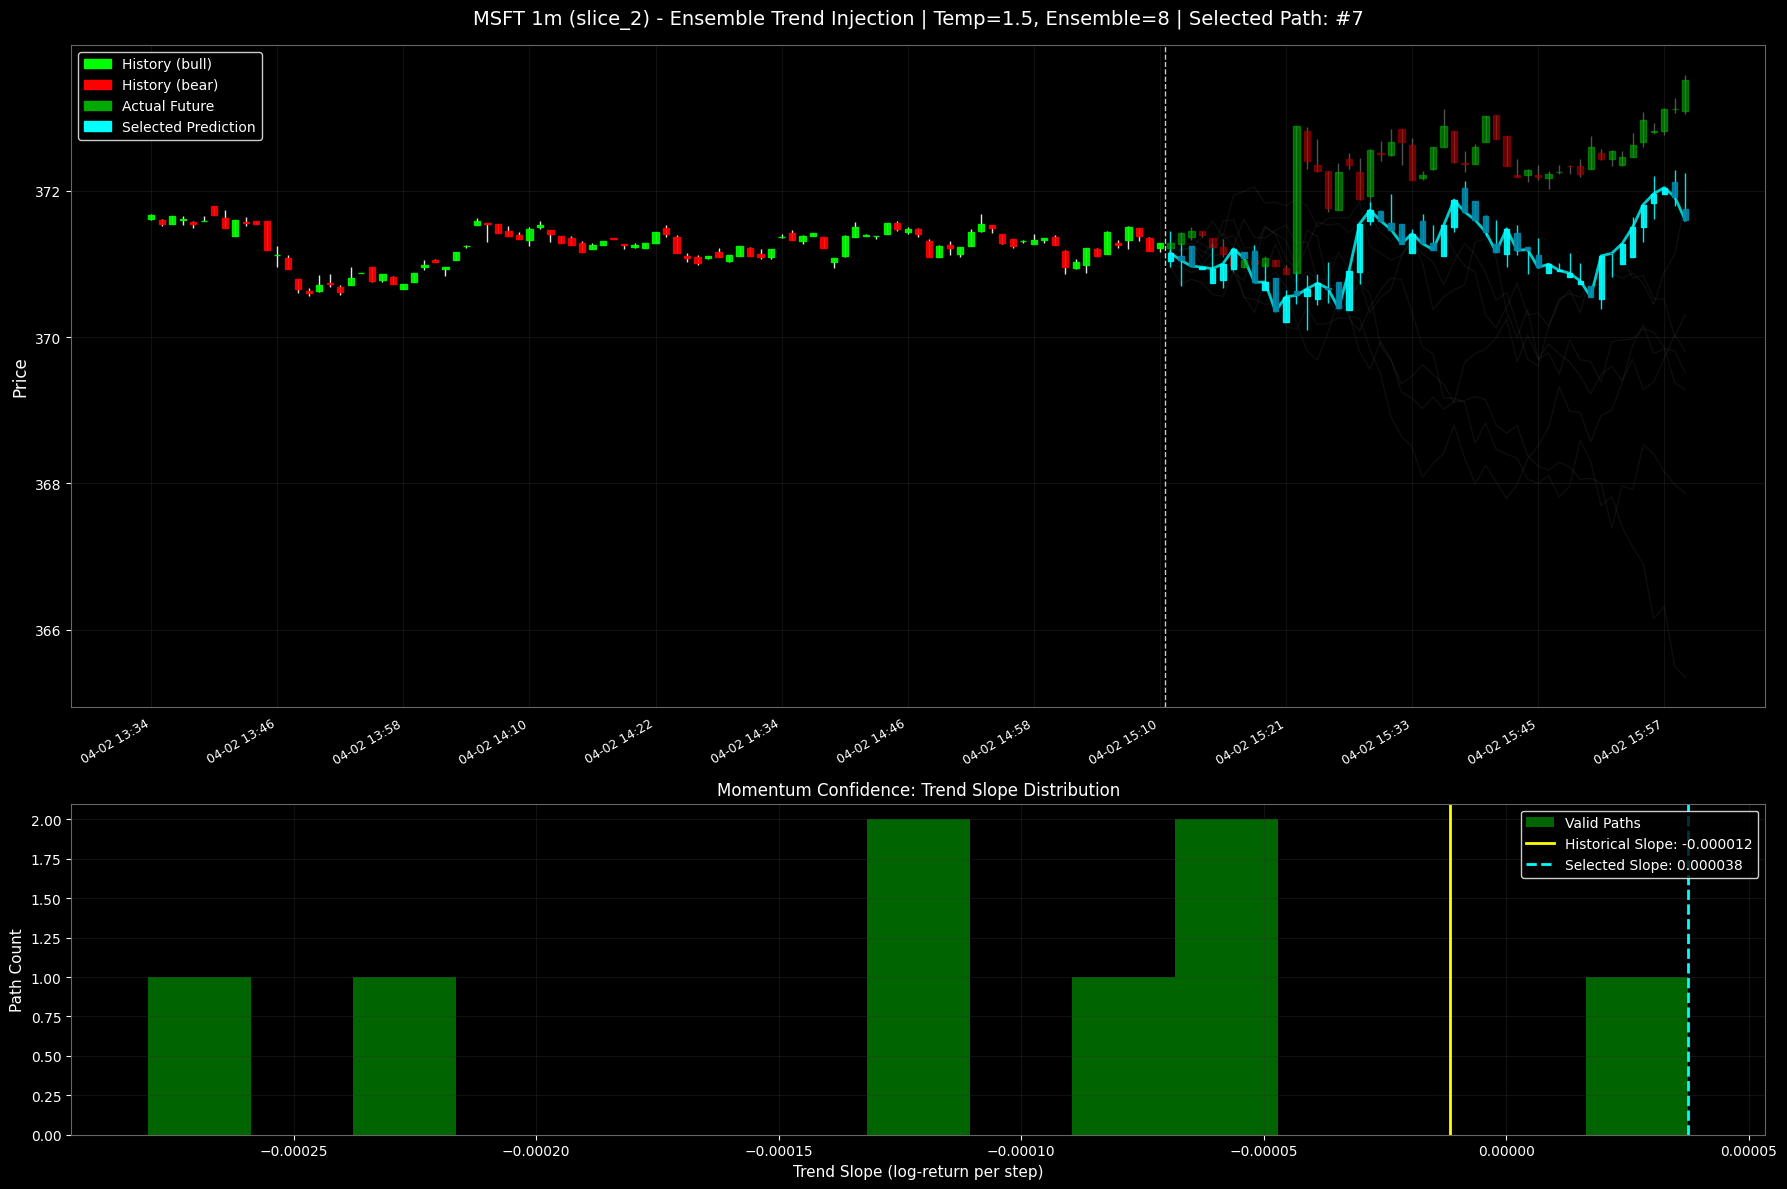


=== Momentum Confidence Report ===
Historical trend (last 20 bars): -0.000012
Strong trend detected: False
Paths rejected (wrong direction): 0/8
Selected path index: 7
Selected path slope: 0.000038
Slope difference: 0.000049

All path slopes: ['-0.0001', '-0.0003', '-0.0001', '-0.0001', '-0.0001', '-0.0002', '-0.0001', '0.0000']


In [35]:
if fold_results:
    latest = fold_results[-1]
    ensemble_info = latest['ensemble_info']
    selection_info = ensemble_info['selection_info']

    fig, axes = plt.subplots(2, 1, figsize=(18, 12), facecolor='black', 
                            gridspec_kw={'height_ratios': [2, 1]})
    ax_main = axes[0]
    ax_trend = axes[1]
    ax_main.set_facecolor('black')
    ax_trend.set_facecolor('black')

    def draw_candles(ax, ohlc, start_x, up_edge, up_face, down_edge, down_face, wick_color, width=0.6, alpha=1.0):
        vals = ohlc[OHLC_COLS].to_numpy()
        for i, (o, h, l, c) in enumerate(vals):
            x = start_x + i
            bull = c >= o
            ax.vlines(x, l, h, color=wick_color, linewidth=1.0, alpha=alpha, zorder=2)
            lower = min(o, c)
            height = max(abs(c - o), 1e-6)
            rect = Rectangle((x - width/2, lower), width, height,
                           facecolor=up_face if bull else down_face,
                           edgecolor=up_edge if bull else down_edge,
                           linewidth=1.0, alpha=alpha, zorder=3)
            ax.add_patch(rect)

    def draw_path_line(ax, price_path, start_x, color, alpha=0.3, linewidth=1, label=None):
        """Draw a simple line path showing close prices"""
        closes = price_path[:, 3]  # Close column
        x_vals = np.arange(len(closes)) + start_x
        ax.plot(x_vals, closes, color=color, alpha=alpha, linewidth=linewidth, label=label)

    context_df = latest['context_df']
    actual_future_df = latest['actual_future_df']
    pred_future_df = latest['pred_future_df']

    # Draw history (green/red)
    draw_candles(ax_main, context_df, 0, '#00FF00', '#00FF00', '#FF0000', '#FF0000', '#FFFFFF', width=0.6, alpha=0.9)

    # Draw all ensemble paths as faint lines
    all_price_paths = ensemble_info['all_price_paths']
    best_idx = ensemble_info['best_idx']

    for i, path_prices in enumerate(all_price_paths):
        if i == best_idx:
            continue  # Skip best path, will draw separately
        # Color based on whether path was valid
        if selection_info['valid_mask'][i]:
            color = '#444444'  # Valid but not selected
            alpha = 0.2
        else:
            color = '#330000'  # Rejected (wrong direction)
            alpha = 0.15
        draw_path_line(ax_main, path_prices, len(context_df), color, alpha=alpha, linewidth=1)

    # Draw best path (bright)
    draw_path_line(ax_main, all_price_paths[best_idx], len(context_df), '#00FFFF', alpha=0.8, 
                   linewidth=2, label=f'Best Path (#{best_idx})')

    # Draw actual future (dimmed candles)
    draw_candles(ax_main, actual_future_df, len(context_df), '#00AA00', '#00AA00', '#AA0000', '#AA0000', '#888888', 
                 width=0.6, alpha=0.6)

    # Draw selected prediction (bright candles)
    draw_candles(ax_main, pred_future_df, len(context_df), '#00FFFF', '#00FFFF', '#0088AA', '#0088AA', '#00FFFF',
                 width=0.5, alpha=0.9)

    ax_main.axvline(len(context_df) - 0.5, color='white', linestyle='--', linewidth=1.0, alpha=0.8)

    # Labels for main chart
    n = len(context_df) + len(actual_future_df)
    step = max(1, n // 12)
    ticks = list(range(0, n, step))
    all_idx = context_df.index.append(actual_future_df.index)
    labels = [all_idx[i].strftime('%m-%d %H:%M') for i in ticks if i < len(all_idx)]

    ax_main.set_xticks(ticks)
    ax_main.set_xticklabels(labels, rotation=30, ha='right', color='white', fontsize=9)
    ax_main.tick_params(axis='y', colors='white')
    for sp in ax_main.spines.values():
        sp.set_color('#666666')
    ax_main.grid(color='#333333', linewidth=0.5, alpha=0.5)

    title_text = (f"MSFT 1m ({latest['fold']}) - Ensemble Trend Injection | "
                  f"Temp={SAMPLING_TEMPERATURE}, Ensemble={ENSEMBLE_SIZE} | "
                  f"Selected Path: #{best_idx}")
    ax_main.set_title(title_text, color='white', fontsize=14, pad=15)
    ax_main.set_ylabel('Price', color='white', fontsize=12)

    # Legend for main chart
    legend_elements = [
        Patch(facecolor='#00FF00', edgecolor='#00FF00', label='History (bull)'),
        Patch(facecolor='#FF0000', edgecolor='#FF0000', label='History (bear)'),
        Patch(facecolor='#00AA00', edgecolor='#00AA00', label='Actual Future'),
        Patch(facecolor='#00FFFF', edgecolor='#00FFFF', label='Selected Prediction'),
    ]
    ax_main.legend(handles=legend_elements, facecolor='black', edgecolor='white', labelcolor='white', 
                  loc='upper left', fontsize=10)

    # === Trend Analysis Subplot ===
    path_slopes = selection_info['path_slopes']
    historical_slope = selection_info['historical_slope']
    valid_mask = selection_info['valid_mask']

    # Plot histogram of path slopes
    valid_slopes = [s for s, v in zip(path_slopes, valid_mask) if v]
    rejected_slopes = [s for s, v in zip(path_slopes, valid_mask) if not v]

    if valid_slopes:
        ax_trend.hist(valid_slopes, bins=15, color='#00AA00', alpha=0.6, label='Valid Paths')
    if rejected_slopes:
        ax_trend.hist(rejected_slopes, bins=10, color='#AA0000', alpha=0.4, label='Rejected Paths')

    # Mark historical slope
    ax_trend.axvline(historical_slope, color='#FFFF00', linestyle='-', linewidth=2, 
                    label=f'Historical Slope: {historical_slope:.6f}')

    # Mark selected path slope
    selected_slope = selection_info['selected_slope']
    ax_trend.axvline(selected_slope, color='#00FFFF', linestyle='--', linewidth=2,
                    label=f'Selected Slope: {selected_slope:.6f}')

    # Mark strong trend threshold if applicable
    if selection_info['is_strong_trend']:
        thresh = selection_info['strong_threshold']
        if historical_slope > 0:
            ax_trend.axvspan(-thresh*2, -thresh, alpha=0.2, color='red', label='Rejection Zone')
        else:
            ax_trend.axvspan(thresh, thresh*2, alpha=0.2, color='red', label='Rejection Zone')

    ax_trend.set_xlabel('Trend Slope (log-return per step)', color='white', fontsize=11)
    ax_trend.set_ylabel('Path Count', color='white', fontsize=11)
    ax_trend.set_title('Momentum Confidence: Trend Slope Distribution', color='white', fontsize=12)
    ax_trend.tick_params(axis='x', colors='white')
    ax_trend.tick_params(axis='y', colors='white')
    for sp in ax_trend.spines.values():
        sp.set_color('#666666')
    ax_trend.legend(facecolor='black', edgecolor='white', labelcolor='white', loc='upper right')
    ax_trend.grid(color='#333333', linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Print selection details
    print(f"\n=== Momentum Confidence Report ===")
    print(f"Historical trend (last {TREND_LOOKBACK_BARS} bars): {historical_slope:.6f}")
    print(f"Strong trend detected: {selection_info['is_strong_trend']}")
    print(f"Paths rejected (wrong direction): {selection_info['rejected_count']}/{ENSEMBLE_SIZE}")
    print(f"Selected path index: {best_idx}")
    print(f"Selected path slope: {selected_slope:.6f}")
    print(f"Slope difference: {abs(selected_slope - historical_slope):.6f}")
    print(f"\nAll path slopes: {[f'{s:.4f}' for s in path_slopes]}")

## Test Cell: Validation Metrics

In [36]:
# Test Cell: Print validation metrics and visual confirmation
print("=" * 60)
print("VALIDATION TEST CELL - Forecast and Rolling Backtest Metrics")
print("=" * 60)

if fold_results:
    for result in fold_results:
        fold_name = result['fold']
        print(f"\n--- Results for {fold_name} ---")

        # Directional accuracy vs persistence baseline
        model_dir_acc = result['model_metrics']['directional_accuracy_eps']
        persist_dir_acc = result['baseline_metrics']['persistence']['directional_accuracy_eps']
        print(f"Directional Accuracy:")
        print(f"  Model:           {model_dir_acc:.4f} ({model_dir_acc*100:.2f}%)")
        print(f"  Persistence:     {persist_dir_acc:.4f} ({persist_dir_acc*100:.2f}%)")
        print(f"  Improvement:     {(model_dir_acc - persist_dir_acc):+.4f} ({(model_dir_acc - persist_dir_acc)*100:+.2f}%)")

        # Average predicted close vs actual close (bias)
        actual_future = result['actual_future_df']
        pred_future = result['pred_future_df']
        actual_closes = actual_future['Close'].values
        pred_closes = pred_future['Close'].values

        avg_actual = np.mean(actual_closes)
        avg_pred = np.mean(pred_closes)
        bias = avg_pred - avg_actual

        print(f"\nAverage Close Bias:")
        print(f"  Actual avg:      ${avg_actual:.4f}")
        print(f"  Predicted avg:   ${avg_pred:.4f}")
        print(f"  Bias:            ${bias:.4f} ({bias/avg_actual*100:+.4f}%)")

        # Visual confirmation of candle realism
        print(f"\nCandle Realism Check (Selected Path):")
        ohlc_data = pred_future[OHLC_COLS].values

        # Check candle validity
        valid_candles = 0
        total_wicks = []
        total_bodies = []

        for o, h, l, c in ohlc_data:
            # High >= max(Open, Close) and Low <= min(Open, Close)
            is_valid = (h >= max(o, c)) and (l <= min(o, c))
            if is_valid:
                valid_candles += 1

            # Calculate wicks and body
            upper_wick = h - max(o, c)
            lower_wick = min(o, c) - l
            body = abs(c - o)
            total_wicks.append(upper_wick + lower_wick)
            total_bodies.append(body)

        validity_rate = valid_candles / len(ohlc_data)
        avg_wick = np.mean(total_wicks)
        avg_body = np.mean(total_bodies)

        print(f"  Valid candles:   {valid_candles}/{len(ohlc_data)} ({validity_rate*100:.1f}%)")
        print(f"  Avg wick size:   ${avg_wick:.4f}")
        print(f"  Avg body size:   ${avg_body:.4f}")
        print(f"  Wick/Body ratio: {avg_wick/avg_body:.2f}")

        # Ensemble diversity
        ensemble_info = result['ensemble_info']
        all_paths = ensemble_info['all_price_paths']
        final_closes = [path[-1, 3] for path in all_paths]  # Close price at final step
        close_std = np.std(final_closes)
        close_range = max(final_closes) - min(final_closes)

        print(f"\nEnsemble Diversity:")
        print(f"  Final close std: ${close_std:.4f}")
        print(f"  Final close range: ${close_range:.4f}")
        print(f"  Selection info:  Path #{ensemble_info['best_idx']} selected by trend matching")

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

VALIDATION TEST CELL - Forecast and Rolling Backtest Metrics

--- Results for slice_1 ---
Directional Accuracy:
  Model:           0.4676 (46.76%)
  Persistence:     0.7401 (74.01%)
  Improvement:     -0.2725 (-27.25%)

Average Close Bias:
  Actual avg:      $399.0688
  Predicted avg:   $397.9886
  Bias:            $-1.0802 (-0.2707%)

Candle Realism Check (Selected Path):
  Valid candles:   50/50 (100.0%)
  Avg wick size:   $0.1139
  Avg body size:   $0.1995
  Wick/Body ratio: 0.57

Ensemble Diversity:
  Final close std: $1.3427
  Final close range: $4.5503
  Selection info:  Path #4 selected by trend matching

--- Results for slice_2 ---
Directional Accuracy:
  Model:           0.5121 (51.21%)
  Persistence:     0.7368 (73.68%)
  Improvement:     -0.2247 (-22.47%)

Average Close Bias:
  Actual avg:      $372.1826
  Predicted avg:   $371.1743
  Bias:            $-1.0084 (-0.2709%)

Candle Realism Check (Selected Path):
  Valid candles:   50/50 (100.0%)
  Avg wick size:   $0.1781
  Avg

## V8 Extension: Rolling Walk-Forward Backtest (Strictly Causal)
This section adds a full bar-by-bar rolling engine on top of the v7 training pipeline above.

Important:
- Model architecture is unchanged (`Seq2SeqAttnGRU` + `generate_realistic`).
- No checkpoint is required; the model is trained in this notebook first.
- Rolling predictions are strictly causal at anchor time `t` using only `[t-window, ..., t-1]`.

In [37]:
# V8 rolling configuration (frame generator mode)
ROLLINGSTARTTIME = '09:30'
ROLLINGENDTIME = '16:00'
ROLLING_STEP = 1  # 1 = every minute

DEFAULT_ROLLING_TEMPERATURE = 1.5
BASE_ROLLING_TEMPERATURE = DEFAULT_ROLLING_TEMPERATURE
USE_TEMPERATURE_SCHEDULE = True
TEMPERATURESCHEDULE = [
    ('09:30', '10:15', 1.25),
    ('10:15', '14:00', 1.45),
    ('14:00', '16:00', 1.60),
]

ROLLING_BACKTEST_DATE = None  # e.g. '2025-02-13'

FRAME_OUTPUT_DIR = Path('output/jupyter-notebook/frames/v9.3')
FRAME_FILENAME_PATTERN = 'frame_{:04d}.png'
FRAME_DPI = 180
FRAME_FIGSIZE = (18, 8)
FRAME_HISTORY_BARS = 220

print({
    'ROLLINGSTARTTIME': ROLLINGSTARTTIME,
    'ROLLINGENDTIME': ROLLINGENDTIME,
    'ROLLING_STEP': ROLLING_STEP,
    'DEFAULT_ROLLING_TEMPERATURE': DEFAULT_ROLLING_TEMPERATURE,
    'USE_TEMPERATURE_SCHEDULE': USE_TEMPERATURE_SCHEDULE,
    'ROLLING_BACKTEST_DATE': ROLLING_BACKTEST_DATE,
    'FRAME_OUTPUT_DIR': str(FRAME_OUTPUT_DIR),
    'FRAME_DPI': FRAME_DPI,
})


{'ROLLINGSTARTTIME': '09:30', 'ROLLINGENDTIME': '16:00', 'ROLLING_STEP': 1, 'DEFAULT_ROLLING_TEMPERATURE': 1.5, 'USE_TEMPERATURE_SCHEDULE': True, 'ROLLING_BACKTEST_DATE': None, 'FRAME_OUTPUT_DIR': 'output\\jupyter-notebook\\frames\\v9.3', 'FRAME_DPI': 180}


In [38]:
# Train a v7 model for rolling backtest (no checkpoint needed)
def _intraday_positions_for_date(df: pd.DataFrame, date_str: str, start_time: str, end_time: str) -> np.ndarray:
    idx = df.index
    day_mask = (idx.strftime('%Y-%m-%d') == date_str)
    st = pd.Timestamp(start_time).time()
    et = pd.Timestamp(end_time).time()
    time_mask = np.array([(t >= st) and (t < et) for t in idx.time], dtype=bool)
    return np.where(day_mask & time_mask)[0]


def _select_backtest_date(df: pd.DataFrame, requested: Optional[str], window: int, horizon: int) -> str:
    if requested is not None:
        pos = _intraday_positions_for_date(df, requested, ROLLINGSTARTTIME, ROLLINGENDTIME)
        if len(pos) == 0:
            raise ValueError(f'No intraday bars for requested date: {requested}')
        if pos[0] < window:
            raise ValueError(f'Requested date {requested} does not have enough prior bars for window={window}')
        if pos[-1] + horizon >= len(df):
            raise ValueError(f'Requested date {requested} lacks future bars for horizon={horizon}')
        return requested

    # Auto-pick latest valid date excluding final date to ensure future bars for full 390 anchors.
    dates = sorted(pd.Index(df.index.strftime('%Y-%m-%d')).unique())
    if len(dates) < 2:
        raise RuntimeError('Need at least 2 trading dates for rolling backtest with full horizon labels.')

    for d in reversed(dates[:-1]):
        pos = _intraday_positions_for_date(df, d, ROLLINGSTARTTIME, ROLLINGENDTIME)
        if len(pos) < 390:
            continue
        if pos[0] < window:
            continue
        if pos[-1] + horizon >= len(df):
            continue
        return d

    raise RuntimeError('Could not auto-select a valid backtest date with full intraday coverage.')


def train_v7_model_for_rolling(
    price_df_full: pd.DataFrame,
    window: int,
    horizon: int,
    backtest_date: str,
) -> Tuple[nn.Module, pd.DataFrame, np.ndarray, np.ndarray, pd.DataFrame]:
    feat_all = build_feature_frame(price_df_full)
    target_all = build_target_frame(feat_all)

    all_dates = feat_all.index.strftime('%Y-%m-%d')
    train_day_mask = all_dates < backtest_date
    if train_day_mask.sum() < (window + horizon + 500):
        raise RuntimeError(
            f'Not enough pre-backtest bars before {backtest_date}: {train_day_mask.sum()} rows.'
        )

    input_raw = feat_all[BASE_FEATURE_COLS].to_numpy(np.float32)
    target_raw = target_all[TARGET_COLS].to_numpy(np.float32)
    row_imputed = feat_all['row_imputed'].to_numpy(np.int8).astype(bool)
    row_open_skip = feat_all['row_open_skip'].to_numpy(np.int8).astype(bool)
    prev_close = feat_all['prev_close'].to_numpy(np.float32)

    # Fit scaler using ONLY pre-backtest rows (causal-safe scaling).
    pre_idx = np.where(train_day_mask)[0]
    fit_end = int(pre_idx[-1]) + 1

    in_mean = input_raw[:fit_end].mean(axis=0)
    in_std = input_raw[:fit_end].std(axis=0)
    in_std = np.where(in_std < 1e-8, 1.0, in_std)
    input_scaled = ((input_raw - in_mean) / in_std).astype(np.float32)

    # v7 target setup (no target scaling)
    target_scaled = target_raw.copy()

    X_all, y_all_s, y_all_r, starts, prev_close_starts, drop_imp, drop_skip = make_multistep_windows(
        input_scaled=input_scaled,
        target_scaled=target_scaled,
        target_raw=target_raw,
        row_imputed=row_imputed,
        row_open_skip=row_open_skip,
        starts_prev_close=prev_close,
        window=window,
        horizon=horizon,
    )

    if len(X_all) == 0:
        raise RuntimeError('No windows available after filtering.')

    # Keep windows whose prediction horizon end is strictly before backtest date.
    end_idx = starts + horizon - 1
    end_dates = feat_all.index[end_idx].strftime('%Y-%m-%d')
    usable = end_dates < backtest_date

    X_all = X_all[usable]
    y_all_s = y_all_s[usable]
    y_all_r = y_all_r[usable]

    if len(X_all) < 1000:
        raise RuntimeError(f'Not enough usable windows before backtest date ({len(X_all)}).')

    split = int(len(X_all) * 0.85)
    X_train, y_train_s, y_train_r = X_all[:split], y_all_s[:split], y_all_r[:split]
    X_val, y_val_s, y_val_r = X_all[split:], y_all_s[split:], y_all_r[split:]

    train_loader = DataLoader(
        MultiStepDataset(X_train, y_train_s, y_train_r),
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=PIN_MEMORY,
        num_workers=TRAIN_NUM_WORKERS,
    )
    val_loader = DataLoader(
        MultiStepDataset(X_val, y_val_s, y_val_r),
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=PIN_MEMORY,
        num_workers=TRAIN_NUM_WORKERS,
    )

    clear_torch_memory()
    model = Seq2SeqAttnGRU(
        input_size=X_train.shape[-1],
        output_size=len(TARGET_COLS),
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        hidden_size=HIDDEN_SIZE,
        num_gru_layers=NUM_LAYERS,
        dropout=DROPOUT,
        horizon=horizon,
    ).to(DEVICE)

    print({
        'train_windows': len(X_train),
        'val_windows': len(X_val),
        'dropped_target_imputed': int(drop_imp),
        'dropped_target_open_skip': int(drop_skip),
        'backtest_date': backtest_date,
    })

    history_df = train_model(model, train_loader, val_loader, max_epochs=FINAL_MAX_EPOCHS, patience=FINAL_PATIENCE)
    clear_torch_memory()
    return model, feat_all, in_mean.astype(np.float32), in_std.astype(np.float32), history_df


ROLLING_BACKTEST_DATE = _select_backtest_date(price_df, ROLLING_BACKTEST_DATE, DEFAULT_LOOKBACK, HORIZON)
print(f'Selected rolling backtest date: {ROLLING_BACKTEST_DATE}')

rolling_model, rolling_feat_df, rolling_in_mean, rolling_in_std, rolling_train_history = train_v7_model_for_rolling(
    price_df_full=price_df,
    window=DEFAULT_LOOKBACK,
    horizon=HORIZON,
    backtest_date=ROLLING_BACKTEST_DATE,
)

print('Rolling model trained and ready.')

Selected rolling backtest date: 2026-04-01
{'train_windows': 19453, 'val_windows': 3434, 'dropped_target_imputed': 3128, 'dropped_target_open_skip': 4241, 'backtest_date': '2026-04-01'}


C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\283891517.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP and DEVICE.type == 'cuda')
C:\Users\Arya\AppData\Local\Temp\ipykernel_16860\2050938697.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=torch.float16)


Epoch 01 | tf=1.000 | train=-5.419153 (nll=-5.477654) | val=-7.020202 (nll=-7.067404) | lr=0.0005
Epoch 02 | tf=0.950 | train=-6.659672 (nll=-6.708880) | val=-6.528108 (nll=-6.579407) | lr=0.0005
Epoch 03 | tf=0.902 | train=-7.534520 (nll=-7.583800) | val=-7.934048 (nll=-7.981249) | lr=0.0005
Epoch 04 | tf=0.857 | train=-7.678666 (nll=-7.727921) | val=-7.353456 (nll=-7.404756) | lr=0.0005
Epoch 05 | tf=0.815 | train=-8.025147 (nll=-8.074347) | val=-8.520646 (nll=-8.571945) | lr=0.0005
Epoch 06 | tf=0.774 | train=-8.502480 (nll=-8.551764) | val=-8.911344 (nll=-8.958546) | lr=0.0005
Epoch 07 | tf=0.735 | train=-8.804673 (nll=-8.853935) | val=-8.976915 (nll=-9.027429) | lr=0.0005
Epoch 08 | tf=0.698 | train=-8.772455 (nll=-8.821650) | val=-9.002001 (nll=-9.053252) | lr=0.0005
Epoch 09 | tf=0.663 | train=-8.944811 (nll=-8.993834) | val=-8.969408 (nll=-9.020707) | lr=0.0005
Epoch 10 | tf=0.630 | train=-9.021338 (nll=-9.070492) | val=-9.032756 (nll=-9.084053) | lr=0.0005
Epoch 11 | tf=0.599 

In [39]:
# Rolling log structure + strictly causal rolling engine
@dataclass
class RollingPredictionLog:
    anchortime: pd.Timestamp
    contextendprice: float
    predictedpath: pd.DataFrame
    actualpath: pd.DataFrame
    predictionhorizon: int
    temperature: float
    context_start_idx: int
    context_end_idx: int  # exclusive; equals anchor position

    step_mae: Optional[np.ndarray] = None
    directional_hit: Optional[bool] = None

    def __post_init__(self):
        assert len(self.predictedpath) == self.predictionhorizon
        assert len(self.actualpath) == self.predictionhorizon
        assert self.predictedpath.index[0] == self.anchortime, (
            f'Off-by-one: first prediction ts {self.predictedpath.index[0]} != anchor {self.anchortime}'
        )
        assert self.actualpath.index[0] == self.anchortime, (
            f'Off-by-one: first actual ts {self.actualpath.index[0]} != anchor {self.anchortime}'
        )

    def compute_metrics(self):
        p = self.predictedpath['Close'].to_numpy(np.float32)
        a = self.actualpath['Close'].to_numpy(np.float32)
        self.step_mae = np.abs(p - a)
        self.directional_hit = bool(np.sign(p[0] - self.contextendprice) == np.sign(a[0] - self.contextendprice))
        return self


class RollingBacktester:
    def __init__(
        self,
        model: nn.Module,
        pricedf: pd.DataFrame,
        featuredf: pd.DataFrame,
        input_mean: np.ndarray,
        input_std: np.ndarray,
        windowsize: int,
        horizon: int,
    ):
        self.model = model.to(DEVICE)
        self.model.eval()
        self.pricedf = pricedf.copy()
        self.featuredf = featuredf.copy()
        self.input_mean = input_mean.astype(np.float32)
        self.input_std = np.where(input_std.astype(np.float32) < 1e-8, 1.0, input_std.astype(np.float32))
        self.windowsize = int(windowsize)
        self.horizon = int(horizon)

        self.input_raw = self.featuredf[BASE_FEATURE_COLS].to_numpy(np.float32)
        self.input_scaled = ((self.input_raw - self.input_mean) / self.input_std).astype(np.float32)
        self.row_imputed = self.featuredf['row_imputed'].to_numpy(np.int8).astype(bool)

        self.ts_to_pos = {ts: i for i, ts in enumerate(self.featuredf.index)}
        self.day_anchor_positions: Optional[np.ndarray] = None
        self.selected_anchor_positions: Optional[np.ndarray] = None

    def _temperature_for_time(self, ts: pd.Timestamp) -> float:
        if not USE_TEMPERATURE_SCHEDULE:
            return float(DEFAULT_ROLLING_TEMPERATURE)
        t = ts.time()
        for st_s, en_s, temp in TEMPERATURESCHEDULE:
            st = pd.Timestamp(st_s).time()
            en = pd.Timestamp(en_s).time()
            if st <= t < en:
                return float(temp)
        return float(DEFAULT_ROLLING_TEMPERATURE)

    def _hist_vol(self, context_start: int, context_end: int) -> float:
        closes = self.pricedf['Close'].iloc[context_start:context_end].to_numpy(np.float32)
        if len(closes) < 2:
            return 0.001
        lr = np.log(closes[1:] / np.maximum(closes[:-1], 1e-8))
        return max(float(np.std(lr)), MIN_PREDICTED_VOL)

    @torch.no_grad()
    def _predict_path(self, context_start: int, context_end: int, temperature: float) -> np.ndarray:
        # Context is strictly [context_start, context_end), i.e. last visible bar is context_end-1.
        assert context_end - context_start == self.windowsize
        x_raw = self.input_scaled[context_start:context_end]
        imp_frac = float(self.row_imputed[context_start:context_end].mean())
        imp_col = np.full((self.windowsize, 1), imp_frac, dtype=np.float32)
        x_aug = np.concatenate([x_raw, imp_col], axis=1)
        x_tensor = torch.from_numpy(x_aug).unsqueeze(0).float().to(DEVICE)

        hist_vol = self._hist_vol(context_start, context_end)
        pred_ret = self.model.generate_realistic(x_tensor, temperature=temperature, historical_vol=hist_vol)[0]
        return pred_ret.detach().cpu().numpy()

    def runrollingbacktest(self, starttime: str, endtime: str, date: str, step: int = 1) -> Tuple[List[RollingPredictionLog], int]:
        idx = self.featuredf.index
        st = pd.Timestamp(starttime).time()
        en = pd.Timestamp(endtime).time()
        mask = (idx.strftime('%Y-%m-%d') == date) & np.array([(t >= st) and (t < en) for t in idx.time], dtype=bool)
        anchor_positions = np.where(mask)[0]

        if len(anchor_positions) == 0:
            raise RuntimeError(f'No anchors for date={date} {starttime}-{endtime}')

        selected = anchor_positions[::step]
        self.day_anchor_positions = anchor_positions
        self.selected_anchor_positions = selected

        logs: List[RollingPredictionLog] = []

        pbar = tqdm(total=len(selected), desc=f'Processing minute 0/{len(selected)}')
        for k, anchor_pos in enumerate(selected, start=1):
            context_end = int(anchor_pos)
            context_start = context_end - self.windowsize
            if context_start < 0:
                continue

            # position of this anchor inside same-day sequence
            day_idx = np.searchsorted(anchor_positions, anchor_pos)
            valid_steps = min(self.horizon, len(anchor_positions) - day_idx)
            if valid_steps <= 0:
                continue

            prediction_time = idx[context_end]
            context = self.featuredf.iloc[context_start:context_end]

            # CRITICAL strict-causality check requested by user
            assert context.index[-1] < prediction_time, (
                f'Causality violation: context last {context.index[-1]} is not before prediction {prediction_time}'
            )

            temp = self._temperature_for_time(prediction_time)
            pred_rets_full = self._predict_path(context_start, context_end, temp)
            pred_rets = pred_rets_full[:valid_steps]

            context_close = float(self.featuredf['prev_close'].iloc[context_end])
            pred_prices = returns_to_prices_seq(pred_rets, context_close)

            future_positions = anchor_positions[day_idx: day_idx + valid_steps]
            pred_index = idx[future_positions]
            pred_df = pd.DataFrame(pred_prices, index=pred_index, columns=OHLC_COLS)
            actual_df = self.pricedf[OHLC_COLS].iloc[future_positions].copy()

            log = RollingPredictionLog(
                anchortime=prediction_time,
                contextendprice=context_close,
                predictedpath=pred_df,
                actualpath=actual_df,
                predictionhorizon=valid_steps,
                temperature=temp,
                context_start_idx=context_start,
                context_end_idx=context_end,
            ).compute_metrics()
            logs.append(log)

            pbar.set_description(f'Processing minute {k}/{len(selected)}')
            pbar.update(1)

        pbar.close()

        expected_count = len(selected)
        return logs, expected_count


def runrollingbacktest(model, pricedf, windowsize, starttime, endtime):
    rb = RollingBacktester(
        model=model,
        pricedf=pricedf,
        featuredf=rolling_feat_df,
        input_mean=rolling_in_mean,
        input_std=rolling_in_std,
        windowsize=windowsize,
        horizon=HORIZON,
    )
    return rb.runrollingbacktest(starttime=starttime, endtime=endtime, date=ROLLING_BACKTEST_DATE, step=ROLLING_STEP), rb

In [42]:
from tqdm import tqdm
# Run rolling backtest + required validation asserts
(rolling_logs, expected_prediction_count), rolling_backtester = runrollingbacktest(
    model=rolling_model,
    pricedf=price_df,
    windowsize=DEFAULT_LOOKBACK,
    starttime=ROLLINGSTARTTIME,
    endtime=ROLLINGENDTIME,
)

if len(rolling_logs) == 0:
    raise RuntimeError('No rolling logs produced.')

# Required assert 1: first prediction timestamp equals anchor timestamp
assert rolling_logs[0].predictedpath.index[0] == rolling_logs[0].anchortime, (
    'first prediction first candle timestamp does not equal prediction anchor time'
)

# Required assert 2: no prediction uses future context
for log in rolling_logs:
    anchor_pos = rolling_backtester.ts_to_pos[log.anchortime]
    assert log.context_end_idx == anchor_pos, 'context_end_idx must equal anchor position'
    assert (log.context_end_idx - 1) < anchor_pos, 'context must strictly end at t-1'

# Required assert 3: prediction count equals expected minute anchors for this run
assert len(rolling_logs) == expected_prediction_count, (
    f'prediction count mismatch: {len(rolling_logs)} != {expected_prediction_count}'
)

print({
    'rolling_date': ROLLING_BACKTEST_DATE,
    'predictions_generated': len(rolling_logs),
    'expected_prediction_count': expected_prediction_count,
    'first_anchor': str(rolling_logs[0].anchortime),
    'first_prediction_first_ts': str(rolling_logs[0].predictedpath.index[0]),
    'last_horizon_steps': rolling_logs[-1].predictionhorizon,
})
if hasattr(rolling_backtester, 'get_regime_summary'):
    print({'regime_summary': rolling_backtester.get_regime_summary()})


Processing minute 390/390: 100%|█████████████████████████████████████████████████████| 390/390 [00:15<00:00, 25.93it/s]

{'rolling_date': '2026-04-01', 'predictions_generated': 390, 'expected_prediction_count': 390, 'first_anchor': '2026-04-01 09:30:00', 'first_prediction_first_ts': '2026-04-01 09:30:00', 'last_horizon_steps': np.int64(1)}


In [43]:
# Generate standalone rolling frames (no fan overlays)
def _draw_candles(
    ax,
    ohlc_df: pd.DataFrame,
    start_x: int,
    up_edge: str,
    up_face: str,
    down_edge: str,
    down_face: str,
    wick_color: str,
    width: float = 0.58,
    lw: float = 1.0,
    alpha: float = 1.0,
):
    vals = ohlc_df[OHLC_COLS].to_numpy(np.float32)
    for i, (o, h, l, c) in enumerate(vals):
        x = start_x + i
        bull = c >= o

        ax.vlines(x, l, h, color=wick_color, linewidth=lw, alpha=alpha, zorder=2)

        lower = min(o, c)
        height = max(abs(c - o), 1e-6)
        rect = Rectangle(
            (x - width / 2, lower),
            width,
            height,
            facecolor=up_face if bull else down_face,
            edgecolor=up_edge if bull else down_edge,
            linewidth=lw,
            alpha=alpha,
            zorder=3,
        )
        ax.add_patch(rect)


def _format_ts(ts: pd.Timestamp) -> str:
    return ts.strftime('%I:%M %p').lstrip('0')


def render_single_frame(
    log: RollingPredictionLog,
    frame_idx: int,
    total_frames: int,
    pricedf: pd.DataFrame,
    history_bars: int = FRAME_HISTORY_BARS,
) -> plt.Figure:
    anchor_pos = rolling_backtester.ts_to_pos[log.anchortime]
    h_start = max(0, anchor_pos - history_bars)
    history_df = pricedf.iloc[h_start:anchor_pos][OHLC_COLS].copy()  # up to t-1 only

    actual_df = log.actualpath.copy()       # t..t+h-1 (same-day valid only)
    pred_df = log.predictedpath.copy()      # predicted t..t+h-1

    fig, ax = plt.subplots(figsize=FRAME_FIGSIZE, facecolor='black')
    FigureCanvasAgg(fig)  # non-interactive backend_agg canvas
    ax.set_facecolor('black')

    # Historical context (bright)
    _draw_candles(ax, history_df, 0,
                  up_edge='#00FF00', up_face='#00FF00',
                  down_edge='#FF0000', down_face='#FF0000',
                  wick_color='#D0D0D0', width=0.60, lw=1.0, alpha=0.95)

    # Actual future first (dim, behind prediction) -- REQUIRED DRAW ORDER
    future_start_x = len(history_df)
    _draw_candles(ax, actual_df, future_start_x,
                  up_edge='#1D6F42', up_face='#1D6F42',
                  down_edge='#8E2F25', down_face='#8E2F25',
                  wick_color='#8E8E8E', width=0.58, lw=0.9, alpha=0.40)

    # Predicted future on top (white/black)
    _draw_candles(ax, pred_df, future_start_x,
                  up_edge='#FFFFFF', up_face='#FFFFFF',
                  down_edge='#FFFFFF', down_face='#000000',
                  wick_color='#F3F3F3', width=0.50, lw=1.2, alpha=1.0)

    # NOW divider
    now_x = len(history_df) - 0.5
    ax.axvline(now_x, color='white', linestyle='--', linewidth=1.0, alpha=0.85, zorder=4)
    ax.text(now_x + 0.8, ax.get_ylim()[1] if len(ax.get_ylim()) == 2 else 0.0, 'NOW', color='white', fontsize=9)

    # Axes ticks from history+future timeline
    full_idx = history_df.index.append(actual_df.index)
    n = len(full_idx)
    step = max(1, n // 10)
    ticks = list(range(0, n, step))
    if ticks[-1] != n - 1:
        ticks.append(n - 1)
    labels = [full_idx[i].strftime('%H:%M') for i in ticks]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=25, ha='right', color='white', fontsize=9)

    ax.tick_params(axis='y', colors='white')
    for sp in ax.spines.values():
        sp.set_color('#666666')

    ax.grid(color='#242424', linewidth=0.6, alpha=0.35)

    header = (
        f"{SYMBOL} 1m | Timestamp: {_format_ts(log.anchortime)} | "
        f"Frame {frame_idx + 1}/{total_frames} | Temp={log.temperature:.2f}"
    )
    ax.set_title(header, color='white', pad=12)
    ax.set_ylabel('Price', color='white')

    # Frame counter corner label
    ax.text(
        0.01, 0.99,
        f'Frame {frame_idx + 1}/{total_frames}',
        transform=ax.transAxes,
        va='top', ha='left', color='white', fontsize=10,
        bbox=dict(facecolor='black', edgecolor='#666666', alpha=0.8, boxstyle='round,pad=0.25'),
    )

    legend_elements = [
        Patch(facecolor='#00FF00', edgecolor='#00FF00', label='History (bull)'),
        Patch(facecolor='#FF0000', edgecolor='#FF0000', label='History (bear)'),
        Patch(facecolor='#1D6F42', edgecolor='#1D6F42', label='Actual Future (dim bull)'),
        Patch(facecolor='#8E2F25', edgecolor='#8E2F25', label='Actual Future (dim bear)'),
        Patch(facecolor='#FFFFFF', edgecolor='#FFFFFF', label='Predicted (bull)'),
        Patch(facecolor='#000000', edgecolor='#FFFFFF', label='Predicted (bear)'),
    ]
    leg = ax.legend(handles=legend_elements, facecolor='black', edgecolor='#666666', loc='upper left')
    for t in leg.get_texts():
        t.set_color('white')

    plt.tight_layout()
    return fig


def generate_rolling_frames(logs: List[RollingPredictionLog], pricedf: pd.DataFrame, output_dir: Path) -> List[Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    total = len(logs)
    saved_paths: List[Path] = []

    pbar = tqdm(total=total, desc=f'Saving frame 0/{total}')
    for i, log in enumerate(logs):
        fig = render_single_frame(
            log=log,
            frame_idx=i,
            total_frames=total,
            pricedf=pricedf,
            history_bars=FRAME_HISTORY_BARS,
        )

        out_path = output_dir / FRAME_FILENAME_PATTERN.format(i)
        fig.savefig(out_path, dpi=FRAME_DPI, facecolor='black', bbox_inches='tight')
        saved_paths.append(out_path)

        # Required cleanup for memory safety
        plt.close('all')

        pbar.set_description(f'Saving frame {i + 1}/{total}')
        pbar.update(1)

    pbar.close()
    return saved_paths


saved_frame_paths = generate_rolling_frames(rolling_logs, price_df, FRAME_OUTPUT_DIR)

print({
    'frames_dir': str(FRAME_OUTPUT_DIR.resolve()),
    'frames_saved': len(saved_frame_paths),
    'first_frame': saved_frame_paths[0].name if saved_frame_paths else None,
    'last_frame': saved_frame_paths[-1].name if saved_frame_paths else None,
})

# Rolling metrics summary
hit_rate = float(np.mean([lg.directional_hit for lg in rolling_logs if lg.directional_hit is not None]))

def _mae_at(step_1_based: int) -> float:
    vals = [float(lg.step_mae[step_1_based - 1]) for lg in rolling_logs if lg.step_mae is not None and len(lg.step_mae) >= step_1_based]
    return float(np.mean(vals)) if vals else float('nan')

x = np.arange(HORIZON, dtype=np.float32)
p_slopes, a_slopes = [], []
for lg in rolling_logs:
    p = lg.predictedpath['Close'].to_numpy(np.float32)
    a = lg.actualpath['Close'].to_numpy(np.float32)
    if len(p) == HORIZON and len(a) == HORIZON:
        p_slopes.append(np.polyfit(x, p, 1)[0])
        a_slopes.append(np.polyfit(x, a, 1)[0])
trend_corr = float(np.corrcoef(p_slopes, a_slopes)[0, 1]) if len(p_slopes) > 1 else float('nan')

metrics_table = pd.DataFrame([
    ('Directional hit rate (t+1)', f'{hit_rate:.2%}'),
    ('Path MAE @ step 1', f'${_mae_at(1):.4f}'),
    ('Path MAE @ step 5', f'${_mae_at(5):.4f}'),
    ('Path MAE @ step 10', f'${_mae_at(10):.4f}'),
    ('Path MAE @ step 15', f'${_mae_at(15):.4f}'),
    ('Trend correlation (15-bar slope)', f'{trend_corr:.4f}'),
], columns=['Metric', 'Value'])

display(metrics_table)

Saving frame 390/390: 100%|██████████████████████████████████████████████████████████| 390/390 [04:45<00:00,  1.37it/s]

{'frames_dir': 'D:\\APPS\\Github\\SDP-Technical\\output\\jupyter-notebook\\output\\jupyter-notebook\\frames\\v9.3', 'frames_saved': 390, 'first_frame': 'frame_0000.png', 'last_frame': 'frame_0389.png'}


,Metric,Value
0,Directional hit rate (t+1),49.49%
1,Path MAE @ step 1,$0.2468
2,Path MAE @ step 5,$0.5407
3,Path MAE @ step 10,$0.8296
4,Path MAE @ step 15,$1.0587
5,Trend correlation (15-bar slope),-0.0195


### Validation checklist status
- Strict causality per frame (`assert context.index[-1] < prediction_time`): **asserted**
- First predicted candle timestamp equals anchor timestamp: **asserted**
- Prediction count equals expected minute anchors: **asserted**
- No fan overlays used: **replaced by standalone per-frame PNG rendering**
- Frames saved sequentially to `frames/frame_0000.png ...`: **implemented**